<a href="https://colab.research.google.com/github/ManuelaAndreaBeyer/cleanthesis/blob/master/EI_RNN_NWAnalysis_2026JUN23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Reduced Network Analysis for RNN Paper

Paper: __"MODELLING CHRONIC STRESS AS AN EXCITATORY-INHIBITORY PERTURBATION IN RECURRENT WORKING-MEMORY NETWORKS"__

Collaboration with Mauricio and Janina

This Colab notebook is a reduced version focusing on analyses included in the manuscript:

- naive vs resilient SUpItoE
- Main threshold: None

**Note:** Preliminary analyses considered three phenotypes (*naive*, *resilient SUpItoE*, and *SUprI*). Kruskal–Wallis tests were used for these three-group comparisons (see Mattermost chat: `RNN_NW_Analysis`). Analysis of the four connectivity blocks was initiated but not completed. In these preliminary analyses, the main threshold was set to 0.8.

**AI assistance:** ChatGPT

## Network Architecture

Networks were initialized as fully connected directed graphs without self-connections, yielding **9,900 possible recurrent edges** per network ($N(N-1)=100\times99$). For each condition, **200 independently trained recurrent neural networks** comprising **100 neurons** ($N_{exc}=80$, $N_{inh}=20$) were analyzed.

The recurrent connectivity matrix $W_{rec}\in\mathbb{R}^{N\times N}$ follows the convention

$$
W_{rec}[\mathrm{post},\mathrm{pre}]
$$

such that rows correspond to postsynaptic target neurons and columns to presynaptic source neurons. Thus, an entry $W_{ij}$ denotes a directed connection from neuron $j$ to neuron $i$ (pre $\rightarrow$ post).

Excitatory neurons occupy indices $0,\ldots,N_{exc}-1$, whereas inhibitory neurons occupy indices $N_{exc},\ldots,N-1$. Accordingly, $W_{rec}$ can be partitioned into four biologically interpretable subnetworks:

$$
W_{EE}=W_{rec}[0:N_{exc},\,0:N_{exc}]
$$

$$
W_{EI}=W_{rec}[N_{exc}:N,\,0:N_{exc}]
$$

$$
W_{IE}=W_{rec}[0:N_{exc},\,N_{exc}:N]
$$

$$
W_{II}=W_{rec}[N_{exc}:N,\,N_{exc}:N]
$$

These correspond to excitatory-to-excitatory (**E→E**), excitatory-to-inhibitory (**E→I**), inhibitory-to-excitatory (**I→E**), and inhibitory-to-inhibitory (**I→I**) projections, respectively. Throughout graph construction, edges are represented as directed connections from presynaptic to postsynaptic neurons, consistent with the indexing convention of $W_{rec}$.




E-Mail: miuuu132@gmail.com



### Info

Networks start fully connected, no self connections -> 9900 possible edges

Each condition: 200 networks with 100 nodes each

The recurrent connectivity matrix (W_{rec}) has dimensions (N \times N), where (N=100) neurons in the present networks ((N_{exc}=80), (N_{inh}=20)). Following the convention used throughout the analysis, matrix entries are indexed as

[
W_{rec}[\mathrm{post},\mathrm{pre}],
]

such that rows correspond to postsynaptic target neurons and columns correspond to presynaptic source neurons. Consequently, an entry (W_{ij}) represents a directed connection from neuron (j) to neuron (i) (pre (\rightarrow) post).

Excitatory neurons occupy indices (0,\ldots,N_{exc}-1), whereas inhibitory neurons occupy indices (N_{exc},\ldots,N-1). This indexing allows the recurrent matrix to be partitioned into four biologically interpretable blocks:

[
W_{EE}=W_{rec}[0:N_{exc},,0:N_{exc}],
]

[
W_{EI}=W_{rec}[N_{exc}:N,,0:N_{exc}],
]

[
W_{IE}=W_{rec}[0:N_{exc},,N_{exc}:N],
]

[
W_{II}=W_{rec}[N_{exc}:N,,N_{exc}:N].
]

These correspond to excitatory-to-excitatory (E→E), excitatory-to-inhibitory (E→I), inhibitory-to-excitatory (I→E), and inhibitory-to-inhibitory (I→I) projections, respectively. Throughout graph construction, edges are therefore represented as directed connections from presynaptic to postsynaptic neurons (pre (\rightarrow) post), consistent with the indexing convention of (W_{rec}).




In [2]:
#%% 1 mount drive content
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#%% 2 Imports

import os
import json

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

import networkx as nx

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from scipy.stats import mannwhitneyu

#plt.style.use("ggplot")

In [4]:
#%% 3 Project paths - adjust according to setup/ repository

#TODO define the path to networks folder here:
PROJECT = Path("/content/drive/MyDrive")

NETWORK_ROOT = PROJECT/"networks"

NETWORK_SETS = {
        "naive":
        NETWORK_ROOT/"naive", #==control?

        "resilient":
        NETWORK_ROOT/"resilient_SUpItoE" #manipulation on the cellular/synapse level
}


OUTPUT_ROOT = PROJECT/"ANN_analysis"
IMAGES_DIR = OUTPUT_ROOT/"images"
RESULTS_DIR = OUTPUT_ROOT/"results"
TABLES_DIR = OUTPUT_ROOT/"tables"


for folder in [

        OUTPUT_ROOT,
        IMAGES_DIR,
        RESULTS_DIR,
        TABLES_DIR
]:

    folder.mkdir( # make the folders and save them in the above directory

        parents=True,
        exist_ok=True
    )

print("Folders ready")

Folders ready


In [5]:
#%% 4 Analysis settings

CONDITIONS=[
    "naive",
    "resilient"
]

# I asked for the colors for the paper (see chat Mauricio)
COLORS={
    "naive":"#0072B2",
    "resilient":"#E69F00"
}

N_NETWORKS=200 #200 per condition, n=100 nodes

MAIN_THRESHOLD=.80 #switched to None! #0.8 was threshold in April 2026 and shortly after Canada

ROBUSTNESS_THRESHOLDS=(None,.30,.50,.70,.80,.90)

# preliminary analysis used the 4 blocks and the 3 phenotypes, but in this analysis main focus is on None thereshold and naive vs resilient
BLOCKS_ALL=[
        "E->E",
        "E->I",
        "I->E",
        "I->I"
]

EPS=1e-12

In [6]:
#%% 5 helper functions
# ==========================================================

#timestamp, select preferred version like 2026JUN.._time
def timestamp_now():

    return datetime.now().strftime(
        "%Y%b%d_%H%M"
    ).upper()

# save the plots
def savefig(
        name,
        dpi=300
):

    ts=timestamp_now()


    for ext in [
            "png",
            "svg",
            "pdf"
    ]:


        plt.savefig(

            IMAGES_DIR/
            f"{name}_{ts}.{ext}",
            dpi=dpi,
            bbox_inches="tight"
        )


    print(
        "saved",
        name
    )

def sem(x):
    x=np.asarray(x)
    return np.std(
            x,
            ddof=1
    )/np.sqrt(len(x))

# star definition for the significance *** high to ns not significant
def p_to_stars(p):
    if p<1e-3:

        return "***"
    elif p<1e-2:

        return "**"
    elif p<0.05:
        return "*"
    else:
        return "ns"

In [7]:
#%% 6. Self-contained network loader

def load_checkpoint_simple(filepath):
    """
    Load one saved network checkpoint.

    Expected checkpoint format:
        network_<idx>.npz

    Returns
    -------
    params : dict
        Network parameters, including w_rec, w_in, w_out, x0 if present.

    config : dict
        Training and architecture metadata.

    D : ndarray
        Dale sign matrix.

    out_mask : ndarray
        Output mask.

    connectivity_mask : ndarray
        Structural recurrent connectivity mask.

    step : int or None
        Training step.
    """

    data = np.load(filepath, allow_pickle=False)

    params = {
        key[len("param__") :]: np.array(data[key])
        for key in data.files
        if key.startswith("param__")
    }

    D = np.array(data["D"])
    out_mask = np.array(data["out_mask"])
    connectivity_mask = np.array(data["connectivity_mask"])

    meta = json.loads(bytes(data["_meta"]).decode("utf-8"))
    config = meta["config"]
    step = meta.get("step", None)

    return params, config, D, out_mask, connectivity_mask, step


def effective_W(params, masks, connectivity_mask):
    """
    Construct the effective recurrent weight matrix.

    Convention
    ----------
    W_rec[post, pre]

    rows    = postsynaptic target neurons
    columns = presynaptic source neurons

    Sign convention
    ---------------
    positive weights = excitatory presynaptic neurons
    negative weights = inhibitory presynaptic neurons
    """

    D, _ = masks

    dale_sign = np.diag(np.asarray(D))
    w_rec_nonnegative = np.maximum(np.asarray(params["w_rec"]), 0.0)
    conn = np.asarray(connectivity_mask)

    W_rec = w_rec_nonnegative * dale_sign[None, :] * conn

    return W_rec


def load_W_rec(label, folder, network_idx):
    """
    Load one network and return its effective recurrent matrix.

    Parameters
    ----------
    label : str
        Condition label. Used only for readable error messages.

    folder : str or Path
        Folder containing network_<idx>.npz files.

    network_idx : int
        Network index.

    Returns
    -------
    W_rec : ndarray, shape (N, N)
        Effective recurrent weight matrix.

    N_exc : int
        Number of excitatory neurons.
    """

    folder = Path(folder)
    ckpt_path = folder / f"network_{network_idx}.npz"

    if not ckpt_path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found for {label}, network {network_idx}: {ckpt_path}"
        )

    params, config, D, out_mask, connectivity_mask, step = load_checkpoint_simple(
        ckpt_path
    )

    W_rec = effective_W(
        params=params,
        masks=(D, out_mask),
        connectivity_mask=connectivity_mask,
    )

    N_exc = int(config["N_exc"])

    return W_rec, N_exc


print("Loader functions ready.")

Loader functions ready.


In [8]:
#%% 7 load networks
loaded_networks={}

for condition in CONDITIONS:
    W_list=[]
    folder=NETWORK_SETS[condition]
    print(condition)

    for idx in range(
            N_NETWORKS

    ):

        W_rec,N_exc = load_W_rec(

                    label=condition,
                    folder=folder,
                    network_idx=idx
        )

        W_list.append(
            W_rec
        )

    loaded_networks[condition]={
        "W_rec_list":W_list,
        "N_exc":N_exc,
        "N":W_list[0].shape[0]
    }


print("done")

naive
resilient
done


In [9]:
#%% 8 sanity checks



for label,data in loaded_networks.items():
    print()
    print(label)
    print(

        len(
            data["W_rec_list"]
        )
    )

    print(
        data["W_rec_list"][0].shape
    )

    print(
        data["N_exc"]
    )


naive
200
(100, 100)
80

resilient
200
(100, 100)
80


Saving to:
/content/drive/MyDrive/RNN_NW_density_None_2026JUN24_0628
Saved density values:
/content/drive/MyDrive/RNN_NW_density_None_2026JUN24_0628/density_None_values_2026JUN24_0628.csv


,condition,network_idx,threshold,density,num_edges,n_possible
0,naive,0,None,0.887980,8791,9900
1,naive,1,None,0.828687,8204,9900
2,naive,2,None,0.884545,8757,9900
3,naive,3,None,0.781414,7736,9900
4,naive,4,None,0.632828,6265,9900


Saved stats:
/content/drive/MyDrive/RNN_NW_density_None_2026JUN24_0628/density_None_mannwhitney_stats_2026JUN24_0628.csv


,metric,threshold,naive_n,naive_mean,naive_sd,naive_median,resilient_n,resilient_mean,resilient_sd,resilient_median,U,p,sig
0,density,None,200,0.790177,0.074774,0.807727,200,0.713105,0.087599,0.721667,30414.0,2.115423e-19,***


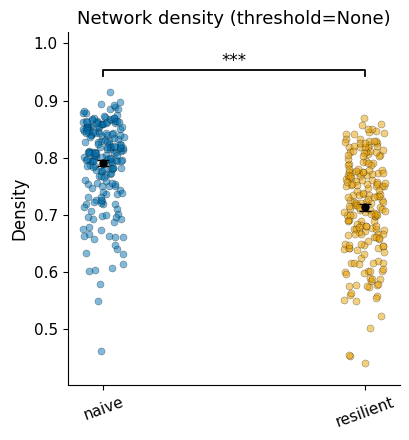

Saved plot files to:
/content/drive/MyDrive/RNN_NW_density_None_2026JUN24_0628


In [13]:
#%%
# ==========================================================
# Density only, threshold None
# naive vs resilient
# Mann-Whitney U test
# Saves png/svg/pdf + stats CSV
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from scipy.stats import mannwhitneyu

RUN_TS_DENSITY = datetime.now().strftime("%Y%b%d_%H%M").upper()

DENSITY_OUT = Path("/content/drive/MyDrive") / f"RNN_NW_density_None_{RUN_TS_DENSITY}"
DENSITY_OUT.mkdir(parents=True, exist_ok=True)

print("Saving to:")
print(DENSITY_OUT)


CONDITION_ORDER = ["naive", "resilient"]

COLORS = {
    "naive": "#0072B2",
    "resilient": "#E69F00",
}


def p_to_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def sem(x):
    x = np.asarray(x, dtype=float)
    return np.std(x, ddof=1) / np.sqrt(len(x))


def add_sig_bar(ax, x1, x2, y, h, text):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y+h, y+h, y],
        lw=1.3,
        color="black"
    )
    ax.text(
        (x1+x2)/2,
        y+h,
        text,
        ha="center",
        va="bottom",
        fontsize=12
    )


def compute_density_none(W_rec):
    """
    Density at threshold None.

    W_rec[post, pre]
    Self-loops excluded.
    All non-zero off-diagonal weights count as edges.
    """
    W = np.asarray(W_rec, dtype=float).copy()

    N = W.shape[0]
    offdiag = ~np.eye(N, dtype=bool)

    A = ((np.abs(W) > 0) & offdiag).astype(int)

    num_edges = int(A.sum())
    n_possible = int(N * (N - 1))

    density = num_edges / n_possible

    return density, num_edges, n_possible


# ----------------------------------------------------------
# Compute density for all networks
# ----------------------------------------------------------

rows = []

for condition in CONDITION_ORDER:

    for network_idx, W_rec in enumerate(
        loaded_networks[condition]["W_rec_list"]
    ):

        density, num_edges, n_possible = compute_density_none(W_rec)

        rows.append({
            "condition": condition,
            "network_idx": network_idx,
            "threshold": "None",
            "density": density,
            "num_edges": num_edges,
            "n_possible": n_possible,
        })


density_df = pd.DataFrame(rows)

density_csv = DENSITY_OUT / f"density_None_values_{RUN_TS_DENSITY}.csv"
density_df.to_csv(density_csv, index=False)

print("Saved density values:")
print(density_csv)

display(density_df.head())


# ----------------------------------------------------------
# Mann-Whitney U statistics
# ----------------------------------------------------------

a = density_df[
    density_df["condition"] == "naive"
]["density"].values

b = density_df[
    density_df["condition"] == "resilient"
]["density"].values

U, p = mannwhitneyu(
    a,
    b,
    alternative="two-sided"
)

stats_df = pd.DataFrame([{
    "metric": "density",
    "threshold": "None",
    "naive_n": len(a),
    "naive_mean": np.mean(a),
    "naive_sd": np.std(a),
    "naive_median": np.median(a),
    "resilient_n": len(b),
    "resilient_mean": np.mean(b),
    "resilient_sd": np.std(b),
    "resilient_median": np.median(b),
    "U": U,
    "p": p,
    "sig": p_to_stars(p),
}])

stats_csv = DENSITY_OUT / f"density_None_mannwhitney_stats_{RUN_TS_DENSITY}.csv"
stats_df.to_csv(stats_csv, index=False)

print("Saved stats:")
print(stats_csv)

display(stats_df)


# ----------------------------------------------------------
# Plot density
# ----------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(4.2, 4.5),
    facecolor="white"
)

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

rng = np.random.default_rng(42)

samples = [a, b]

for x, condition, vals in zip([1, 2], CONDITION_ORDER, samples):

    jitter = rng.uniform(-0.08, 0.08, size=len(vals))

    ax.scatter(

        np.full(len(vals), x) + jitter,

        vals,

        s=26,

        alpha=0.50,

        color=COLORS[condition],

        edgecolor="black",

        linewidth=0.30,

        zorder=2

    )


    ax.errorbar(

        x,

        np.mean(vals),

        yerr=sem(vals),

        fmt='o',

        color='black',

        markersize=5,

        capsize=4,

        lw=1.0,

        zorder=5

    )


# ----------------------------------------------------------
# significance
# ----------------------------------------------------------

y_min = min(np.min(a), np.min(b))
y_max = max(np.max(a), np.max(b))

yr = y_max - y_min

if yr == 0:
    yr = 0.01


add_sig_bar(

        ax,

        1,

        2,

        y_max + 0.06*yr,

        0.02*yr,

        p_to_stars(p)

)



ax.set_ylim(

        y_min - 0.08*yr,

        y_max + 0.22*yr

)


# ----------------------------------------------------------
# cosmetics
# ----------------------------------------------------------

ax.set_xticks([1,2])

ax.set_xticklabels(

        ["naive","resilient"],

        rotation=20

)


ax.set_ylabel(

        "Density",

        fontsize=12

)


ax.set_title(

        "Network density (threshold=None)",

        fontsize=13

)



# publication style

ax.grid(False)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)


ax.tick_params(

        axis='both',

        labelsize=11,

        width=0.8

)



plt.tight_layout()



# ----------------------------------------------------------
# save
# ----------------------------------------------------------

for ext in ["png","svg","pdf"]:


    plot_path = (

        DENSITY_OUT /

        f"density_None_naive_vs_resilient_{RUN_TS_DENSITY}.{ext}"

    )


    fig.savefig(

            plot_path,

            dpi=600,

            facecolor="white",

            edgecolor="none",

            bbox_inches="tight"

    )



plt.show()


print("Saved plot files to:")
print(DENSITY_OUT)

Saving to:
/content/drive/MyDrive/RNN_NW_reciprocity_None_2026JUN24_0728
Saved reciprocity values:
/content/drive/MyDrive/RNN_NW_reciprocity_None_2026JUN24_0728/weighted_directed_reciprocity_None_values_2026JUN24_0728.csv


,condition,network_idx,threshold,reciprocity,reciprocated_weight,total_weight
0,naive,0,None,0.452160,711.789273,1574.196258
1,naive,1,None,0.438333,528.904620,1206.627853
2,naive,2,None,0.450901,798.840590,1771.654362
3,naive,3,None,0.434072,418.979396,965.229564
4,naive,4,None,0.388336,201.103366,517.859190


Saved stats:
/content/drive/MyDrive/RNN_NW_reciprocity_None_2026JUN24_0728/weighted_directed_reciprocity_None_mannwhitney_stats_2026JUN24_0728.csv


,metric,threshold,naive_n,naive_mean,naive_sd,naive_median,resilient_n,resilient_mean,resilient_sd,resilient_median,U,p,sig
0,weighted_directed_reciprocity,None,200,0.435763,0.022709,0.441503,200,0.397724,0.02629,0.398529,35182.0,2.182841e-39,***


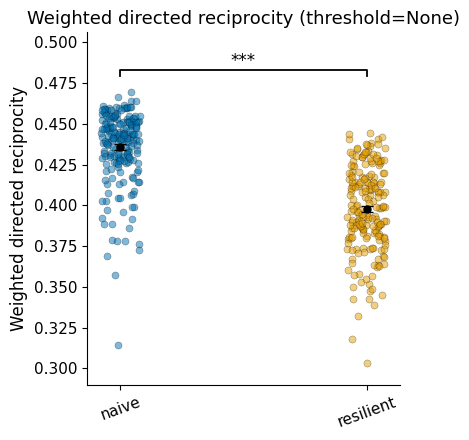

Saved plot files to:
/content/drive/MyDrive/RNN_NW_reciprocity_None_2026JUN24_0728


In [19]:
#%%
# ==========================================================
# Weighted directed reciprocity, threshold None
# naive vs resilient
# Mann-Whitney U test
# Saves png/svg/pdf + stats CSV
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from scipy.stats import mannwhitneyu

RUN_TS_RECIP = datetime.now().strftime("%Y%b%d_%H%M").upper()

RECIP_OUT = Path("/content/drive/MyDrive") / f"RNN_NW_reciprocity_None_{RUN_TS_RECIP}"
RECIP_OUT.mkdir(parents=True, exist_ok=True)

print("Saving to:")
print(RECIP_OUT)


CONDITION_ORDER = ["naive", "resilient"]

COLORS = {
    "naive": "#0072B2",
    "resilient": "#E69F00",
}


def p_to_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def sem(x):
    x = np.asarray(x, dtype=float)
    return np.std(x, ddof=1) / np.sqrt(len(x))


def add_sig_bar(ax, x1, x2, y, h, text):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y+h, y+h, y],
        lw=1.3,
        color="black"
    )
    ax.text(
        (x1+x2)/2,
        y+h,
        text,
        ha="center",
        va="bottom",
        fontsize=12
    )


def compute_weighted_directed_reciprocity_none(W_rec):
    """
    Weighted directed reciprocity at threshold None.

    W_rec[post, pre]
    Self-loops excluded.

    Uses absolute weights because EI networks are signed.
    Reciprocity is the fraction of total directed weight magnitude
    that is reciprocated by the opposite direction.

    r_w = sum_ij min(|w_ij|, |w_ji|) / sum_ij |w_ij|
    """

    W = np.asarray(W_rec, dtype=float).copy()
    N = W.shape[0]

    offdiag = ~np.eye(N, dtype=bool)

    W_abs = np.abs(W)
    W_abs[~offdiag] = 0.0

    total_weight = np.sum(W_abs)

    if total_weight == 0:
        return np.nan, 0.0, 0.0

    reciprocated_weight = np.sum(np.minimum(W_abs, W_abs.T))

    reciprocity = reciprocated_weight / total_weight

    return reciprocity, reciprocated_weight, total_weight


# ----------------------------------------------------------
# Compute reciprocity for all networks
# ----------------------------------------------------------

rows = []

for condition in CONDITION_ORDER:

    for network_idx, W_rec in enumerate(
        loaded_networks[condition]["W_rec_list"]
    ):

        reciprocity, reciprocated_weight, total_weight = (
            compute_weighted_directed_reciprocity_none(W_rec)
        )

        rows.append({
            "condition": condition,
            "network_idx": network_idx,
            "threshold": "None",
            "reciprocity": reciprocity,
            "reciprocated_weight": reciprocated_weight,
            "total_weight": total_weight,
        })


reciprocity_df = pd.DataFrame(rows)

reciprocity_csv = RECIP_OUT / f"weighted_directed_reciprocity_None_values_{RUN_TS_RECIP}.csv"
reciprocity_df.to_csv(reciprocity_csv, index=False)

print("Saved reciprocity values:")
print(reciprocity_csv)

display(reciprocity_df.head())


# ----------------------------------------------------------
# Mann-Whitney U statistics
# ----------------------------------------------------------

a = reciprocity_df[
    reciprocity_df["condition"] == "naive"
]["reciprocity"].dropna().values

b = reciprocity_df[
    reciprocity_df["condition"] == "resilient"
]["reciprocity"].dropna().values

U, p = mannwhitneyu(
    a,
    b,
    alternative="two-sided"
)

stats_df = pd.DataFrame([{
    "metric": "weighted_directed_reciprocity",
    "threshold": "None",
    "naive_n": len(a),
    "naive_mean": np.mean(a),
    "naive_sd": np.std(a, ddof=1),
    "naive_median": np.median(a),
    "resilient_n": len(b),
    "resilient_mean": np.mean(b),
    "resilient_sd": np.std(b, ddof=1),
    "resilient_median": np.median(b),
    "U": U,
    "p": p,
    "sig": p_to_stars(p),
}])

stats_csv = RECIP_OUT / f"weighted_directed_reciprocity_None_mannwhitney_stats_{RUN_TS_RECIP}.csv"
stats_df.to_csv(stats_csv, index=False)

print("Saved stats:")
print(stats_csv)

display(stats_df)


# ----------------------------------------------------------
# Plot reciprocity
# ----------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(4.2, 4.5),
    facecolor="white"
)

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

rng = np.random.default_rng(42)

samples = [a, b]

for x, condition, vals in zip([1, 2], CONDITION_ORDER, samples):

    jitter = rng.uniform(-0.08, 0.08, size=len(vals))

    ax.scatter(
        np.full(len(vals), x) + jitter,
        vals,
        s=26,
        alpha=0.50,
        color=COLORS[condition],
        edgecolor="black",
        linewidth=0.30,
        zorder=2
    )

    ax.errorbar(
        x,
        np.mean(vals),
        yerr=sem(vals),
        fmt='o',
        color='black',
        markersize=5,
        capsize=4,
        lw=1.0,
        zorder=5
    )


# ----------------------------------------------------------
# significance
# ----------------------------------------------------------

y_min = min(np.min(a), np.min(b))
y_max = max(np.max(a), np.max(b))

yr = y_max - y_min

if yr == 0:
    yr = 0.01

add_sig_bar(
    ax,
    1,
    2,
    y_max + 0.06*yr,
    0.02*yr,
    p_to_stars(p)
)

ax.set_ylim(
    max(0, y_min - 0.08*yr),
    min(1.05, y_max + 0.22*yr)
)


# ----------------------------------------------------------
# cosmetics
# ----------------------------------------------------------

ax.set_xticks([1, 2])

ax.set_xticklabels(
    ["naive", "resilient"],
    rotation=20
)

ax.set_ylabel(
    "Weighted directed reciprocity",
    fontsize=12
)

ax.set_title(
    "Weighted directed reciprocity (threshold=None)",
    fontsize=13
)

ax.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.tick_params(
    axis='both',
    labelsize=11,
    width=0.8
)

plt.tight_layout()


# ----------------------------------------------------------
# save
# ----------------------------------------------------------

for ext in ["png", "svg", "pdf"]:

    plot_path = (
        RECIP_OUT /
        f"weighted_directed_reciprocity_None_naive_vs_resilient_{RUN_TS_RECIP}.{ext}"
    )

    fig.savefig(
        plot_path,
        dpi=600,
        facecolor="white",
        edgecolor="none",
        bbox_inches="tight"
    )

plt.show()

print("Saved plot files to:")
print(RECIP_OUT)

In [21]:
!pip install bctpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.4/110.4 kB 2.0 MB/s eta 0:00:00


Saving to:
/content/drive/MyDrive/RNN_NW_primary_metrics_None_2026JUN24_0751
Saved values:
/content/drive/MyDrive/RNN_NW_primary_metrics_None_2026JUN24_0751/primary_metrics_None_values_2026JUN24_0751.csv


,condition,network_idx,threshold,density,num_edges,n_possible,weighted_directed_reciprocity,reciprocated_weight,total_weight,weighted_directed_clustering
0,naive,0,None,0.887980,8791,9900,0.452160,711.789273,1574.196258,0.121630
1,naive,1,None,0.828687,8204,9900,0.438333,528.904620,1206.627853,0.094902
2,naive,2,None,0.884545,8757,9900,0.450901,798.840590,1771.654362,0.138024
3,naive,3,None,0.781414,7736,9900,0.434072,418.979396,965.229564,0.078155
4,naive,4,None,0.632828,6265,9900,0.388336,201.103366,517.859190,0.044359


Saved stats:
/content/drive/MyDrive/RNN_NW_primary_metrics_None_2026JUN24_0751/primary_metrics_None_mannwhitney_stats_2026JUN24_0751.csv


,metric,threshold,naive_n,naive_mean,naive_sd,naive_median,resilient_n,resilient_mean,resilient_sd,resilient_median,U,p,sig
0,density,None,200,0.790177,0.074962,0.807727,200,0.713105,0.087819,0.721667,30414.0,2.115423e-19,***
1,weighted_directed_reciprocity,None,200,0.435763,0.022709,0.441503,200,0.397724,0.026290,0.398529,35182.0,2.182841e-39,***
2,weighted_directed_clustering,None,200,0.090293,0.025532,0.091004,200,0.087765,0.026699,0.087300,21194.0,3.019261e-01,ns


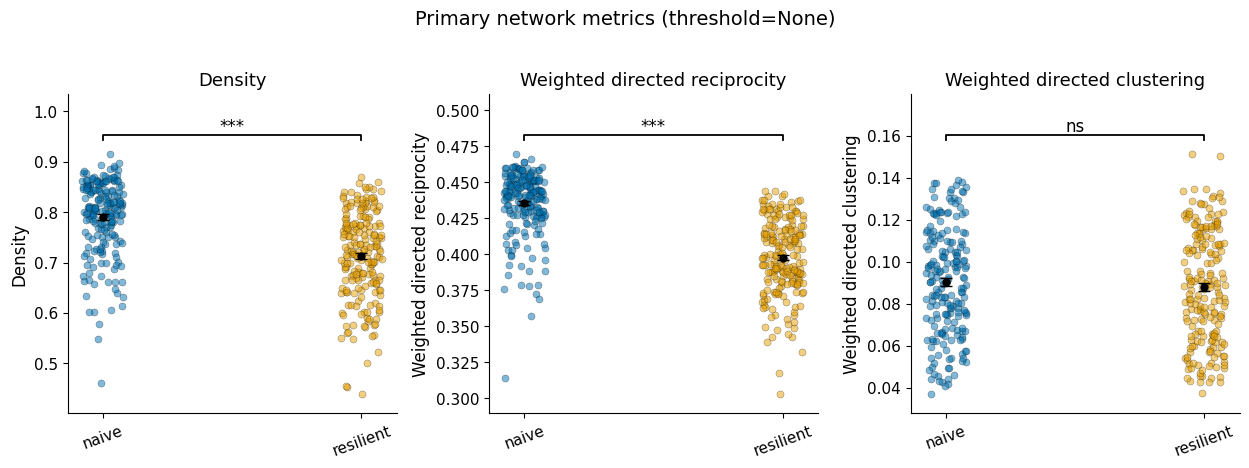

Saved plot files to:
/content/drive/MyDrive/RNN_NW_primary_metrics_None_2026JUN24_0751


In [22]:
#%%
# ==========================================================
# Primary network metrics, threshold None
# Density + weighted directed reciprocity + weighted directed clustering
# naive vs resilient
# Mann-Whitney U test
# Saves png/svg/pdf + stats CSV
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from scipy.stats import mannwhitneyu

# Falls nötig:
# !pip install bctpy

from bct import clustering_coef_wd


RUN_TS = datetime.now().strftime("%Y%b%d_%H%M").upper()

OUT = Path("/content/drive/MyDrive") / f"RNN_NW_primary_metrics_None_{RUN_TS}"
OUT.mkdir(parents=True, exist_ok=True)

print("Saving to:")
print(OUT)


CONDITION_ORDER = ["naive", "resilient"]

COLORS = {
    "naive": "#0072B2",
    "resilient": "#E69F00",
}


def p_to_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def sem(x):
    x = np.asarray(x, dtype=float)
    return np.std(x, ddof=1) / np.sqrt(len(x))


def add_sig_bar(ax, x1, x2, y, h, text):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y+h, y+h, y],
        lw=1.3,
        color="black"
    )
    ax.text(
        (x1+x2)/2,
        y+h,
        text,
        ha="center",
        va="bottom",
        fontsize=12
    )


def compute_density_none(W_rec):
    """
    Binary directed density.
    W_rec[post, pre]
    Self-loops excluded.
    """

    W = np.asarray(W_rec, dtype=float).copy()
    N = W.shape[0]

    offdiag = ~np.eye(N, dtype=bool)

    A = ((np.abs(W) > 0) & offdiag).astype(int)

    num_edges = int(A.sum())
    n_possible = int(N * (N - 1))

    density = num_edges / n_possible

    return density, num_edges, n_possible


def compute_weighted_directed_reciprocity_none(W_rec):
    """
    Weighted directed reciprocity.
    EI/signed weights are converted to absolute magnitudes.

    r_w = sum_ij min(|w_ij|, |w_ji|) / sum_ij |w_ij|
    """

    W = np.asarray(W_rec, dtype=float).copy()
    W_abs = np.abs(W)

    np.fill_diagonal(W_abs, 0.0)

    total_weight = np.sum(W_abs)

    if total_weight == 0:
        return np.nan, 0.0, 0.0

    reciprocated_weight = np.sum(np.minimum(W_abs, W_abs.T))
    reciprocity = reciprocated_weight / total_weight

    return reciprocity, reciprocated_weight, total_weight


def compute_weighted_directed_clustering_none(W_rec):
    """
    Weighted directed clustering coefficient.
    Uses Fagiolo-style weighted directed clustering via bctpy.

    EI/signed weights are converted to absolute magnitudes.
    """

    W = np.asarray(W_rec, dtype=float).copy()
    W_abs = np.abs(W)

    np.fill_diagonal(W_abs, 0.0)

    C_nodes = clustering_coef_wd(W_abs)
    C_mean = np.nanmean(C_nodes)

    return C_mean


# ----------------------------------------------------------
# Compute metrics
# ----------------------------------------------------------

rows = []

for condition in CONDITION_ORDER:

    for network_idx, W_rec in enumerate(
        loaded_networks[condition]["W_rec_list"]
    ):

        density, num_edges, n_possible = compute_density_none(W_rec)

        reciprocity, reciprocated_weight, total_weight = (
            compute_weighted_directed_reciprocity_none(W_rec)
        )

        clustering = compute_weighted_directed_clustering_none(W_rec)

        rows.append({
            "condition": condition,
            "network_idx": network_idx,
            "threshold": "None",
            "density": density,
            "num_edges": num_edges,
            "n_possible": n_possible,
            "weighted_directed_reciprocity": reciprocity,
            "reciprocated_weight": reciprocated_weight,
            "total_weight": total_weight,
            "weighted_directed_clustering": clustering,
        })


metrics_df = pd.DataFrame(rows)

values_csv = OUT / f"primary_metrics_None_values_{RUN_TS}.csv"
metrics_df.to_csv(values_csv, index=False)

print("Saved values:")
print(values_csv)

display(metrics_df.head())


# ----------------------------------------------------------
# Mann-Whitney U stats
# ----------------------------------------------------------

metric_info = {
    "density": "Density",
    "weighted_directed_reciprocity": "Weighted directed reciprocity",
    "weighted_directed_clustering": "Weighted directed clustering",
}

stats_rows = []

for metric in metric_info.keys():

    a = metrics_df[
        metrics_df["condition"] == "naive"
    ][metric].dropna().values

    b = metrics_df[
        metrics_df["condition"] == "resilient"
    ][metric].dropna().values

    U, p = mannwhitneyu(
        a,
        b,
        alternative="two-sided"
    )

    stats_rows.append({
        "metric": metric,
        "threshold": "None",
        "naive_n": len(a),
        "naive_mean": np.mean(a),
        "naive_sd": np.std(a, ddof=1),
        "naive_median": np.median(a),
        "resilient_n": len(b),
        "resilient_mean": np.mean(b),
        "resilient_sd": np.std(b, ddof=1),
        "resilient_median": np.median(b),
        "U": U,
        "p": p,
        "sig": p_to_stars(p),
    })


stats_df = pd.DataFrame(stats_rows)

stats_csv = OUT / f"primary_metrics_None_mannwhitney_stats_{RUN_TS}.csv"
stats_df.to_csv(stats_csv, index=False)

print("Saved stats:")
print(stats_csv)

display(stats_df)


# ----------------------------------------------------------
# Plot all three metrics in one subplot figure
# ----------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12.6, 4.5),
    facecolor="white"
)

fig.patch.set_facecolor("white")

rng = np.random.default_rng(42)

for ax, metric in zip(axes, metric_info.keys()):

    ax.set_facecolor("white")

    a = metrics_df[
        metrics_df["condition"] == "naive"
    ][metric].dropna().values

    b = metrics_df[
        metrics_df["condition"] == "resilient"
    ][metric].dropna().values

    samples = [a, b]

    for x, condition, vals in zip([1, 2], CONDITION_ORDER, samples):

        jitter = rng.uniform(-0.08, 0.08, size=len(vals))

        ax.scatter(
            np.full(len(vals), x) + jitter,
            vals,
            s=26,
            alpha=0.50,
            color=COLORS[condition],
            edgecolor="black",
            linewidth=0.30,
            zorder=2
        )

        ax.errorbar(
            x,
            np.mean(vals),
            yerr=sem(vals),
            fmt="o",
            color="black",
            markersize=5,
            capsize=4,
            lw=1.0,
            zorder=5
        )

    stat_row = stats_df[stats_df["metric"] == metric].iloc[0]

    y_min = min(np.min(a), np.min(b))
    y_max = max(np.max(a), np.max(b))

    yr = y_max - y_min

    if yr == 0:
        yr = 0.01

    add_sig_bar(
        ax,
        1,
        2,
        y_max + 0.06 * yr,
        0.02 * yr,
        stat_row["sig"]
    )

    ax.set_ylim(
        max(0, y_min - 0.08 * yr),
        y_max + 0.25 * yr
    )

    ax.set_xticks([1, 2])

    ax.set_xticklabels(
        ["naive", "resilient"],
        rotation=20
    )

    ax.set_ylabel(
        metric_info[metric],
        fontsize=12
    )

    ax.set_title(
        metric_info[metric],
        fontsize=13
    )

    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        labelsize=11,
        width=0.8
    )


fig.suptitle(
    "Primary network metrics (threshold=None)",
    fontsize=14,
    y=1.03
)

plt.tight_layout()


# ----------------------------------------------------------
# Save plot
# ----------------------------------------------------------

for ext in ["png", "svg", "pdf"]:

    plot_path = OUT / f"primary_metrics_None_naive_vs_resilient_{RUN_TS}.{ext}"

    fig.savefig(
        plot_path,
        dpi=600,
        facecolor="white",
        edgecolor="none",
        bbox_inches="tight"
    )


plt.show()

print("Saved plot files to:")
print(OUT)

Saving to:
/content/drive/MyDrive/RNN_NW_primary_metrics_density_recip_local_eff_None_2026JUN24_0801
Saved values:
/content/drive/MyDrive/RNN_NW_primary_metrics_density_recip_local_eff_None_2026JUN24_0801/primary_metrics_density_recip_local_eff_None_values_2026JUN24_0801.csv


,condition,network_idx,threshold,density,num_edges,n_possible,weighted_directed_reciprocity,reciprocated_weight,total_weight,local_efficiency
0,naive,0,None,0.887980,8791,9900,0.452160,711.789273,1574.196258,0.990001
1,naive,1,None,0.828687,8204,9900,0.438333,528.904620,1206.627853,0.975886
2,naive,2,None,0.884545,8757,9900,0.450901,798.840590,1771.654362,0.989787
3,naive,3,None,0.781414,7736,9900,0.434072,418.979396,965.229564,0.968062
4,naive,4,None,0.632828,6265,9900,0.388336,201.103366,517.859190,0.929250


Saved stats:
/content/drive/MyDrive/RNN_NW_primary_metrics_density_recip_local_eff_None_2026JUN24_0801/primary_metrics_density_recip_local_eff_None_mannwhitney_stats_2026JUN24_0801.csv


,metric,threshold,naive_n,naive_mean,naive_sd,naive_median,resilient_n,resilient_mean,resilient_sd,resilient_median,U,p,sig
0,density,None,200,0.790177,0.074962,0.807727,200,0.713105,0.087819,0.721667,30414.0,2.115423e-19,***
1,weighted_directed_reciprocity,None,200,0.435763,0.022709,0.441503,200,0.397724,0.026290,0.398529,35182.0,2.182841e-39,***
2,local_efficiency,None,200,0.968674,0.018099,0.972748,200,0.950339,0.023309,0.954510,30212.0,1.024672e-18,***


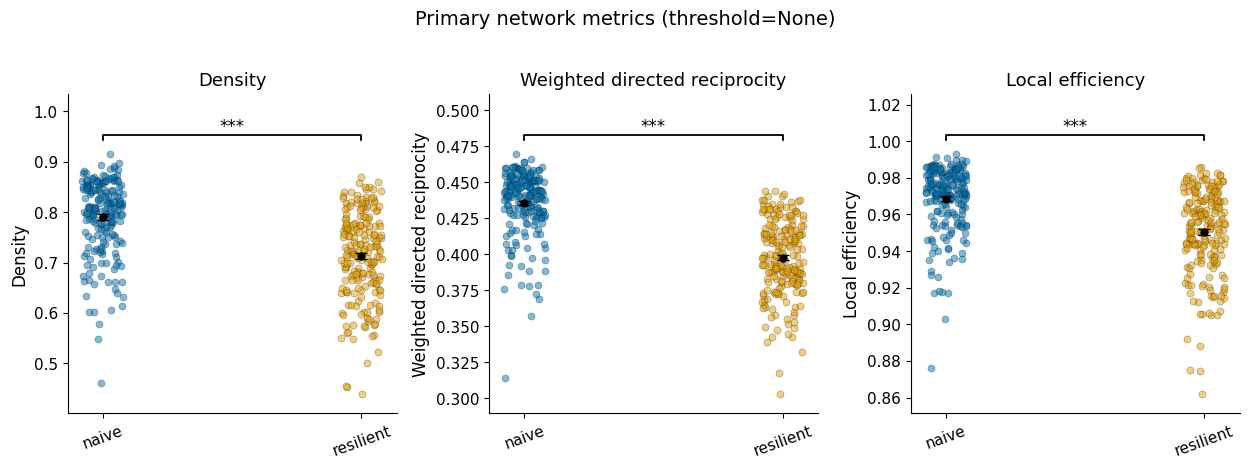

Saved plot files to:
/content/drive/MyDrive/RNN_NW_primary_metrics_density_recip_local_eff_None_2026JUN24_0801


In [24]:
#%%
# ==========================================================
# Primary network metrics, threshold None
# Density + weighted directed reciprocity + local efficiency
# naive vs resilient
# Mann-Whitney U test
# Saves png/svg/pdf + stats CSV
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
from datetime import datetime
from scipy.stats import mannwhitneyu


RUN_TS = datetime.now().strftime("%Y%b%d_%H%M").upper()

OUT = Path("/content/drive/MyDrive") / f"RNN_NW_primary_metrics_density_recip_local_eff_None_{RUN_TS}"
OUT.mkdir(parents=True, exist_ok=True)

print("Saving to:")
print(OUT)


CONDITION_ORDER = ["naive", "resilient"]

COLORS = {
    "naive": "#0072B2",
    "resilient": "#E69F00",
}


def p_to_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def sem(x):
    x = np.asarray(x, dtype=float)
    return np.std(x, ddof=1) / np.sqrt(len(x))


def add_sig_bar(ax, x1, x2, y, h, text):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y+h, y+h, y],
        lw=1.3,
        color="black"
    )
    ax.text(
        (x1+x2)/2,
        y+h,
        text,
        ha="center",
        va="bottom",
        fontsize=12
    )


def compute_density_none(W_rec):
    """
    Binary directed density
    W_rec[post, pre]
    Self-loops excluded
    """

    W = np.asarray(W_rec, dtype=float).copy()
    N = W.shape[0]

    offdiag = ~np.eye(N, dtype=bool)
    A = ((np.abs(W) > 0) & offdiag).astype(int)

    num_edges = int(A.sum())
    n_possible = int(N * (N - 1))

    density = num_edges / n_possible

    return density, num_edges, n_possible


def compute_weighted_directed_reciprocity_none(W_rec):
    """
    Weighted directed reciprocity
    EI/signed weights are converted to absolute magnitudes

    r_w = sum_ij min(|w_ij|, |w_ji|) / sum_ij |w_ij|
    """

    W = np.asarray(W_rec, dtype=float).copy()
    W_abs = np.abs(W)

    np.fill_diagonal(W_abs, 0.0)

    total_weight = np.sum(W_abs)

    if total_weight == 0:
        return np.nan, 0.0, 0.0

    reciprocated_weight = np.sum(np.minimum(W_abs, W_abs.T))
    reciprocity = reciprocated_weight / total_weight

    return reciprocity, reciprocated_weight, total_weight


def compute_local_efficiency_none(W_rec):
    """
    Local efficiency.

    Direction is discarded.
    EI/signed weights are converted to absolute magnitudes.
    Symmetrization uses max(|W_ij|, |W_ji|).

    NetworkX local_efficiency is unweighted.
    Therefore this measures binary local efficiency on the
    undirected support graph.
    """

    W = np.asarray(W_rec, dtype=float).copy()
    W_abs = np.abs(W)

    np.fill_diagonal(W_abs, 0.0)

    W_undir = np.maximum(W_abs, W_abs.T)

    A_undir = (W_undir > 0).astype(int)

    G = nx.from_numpy_array(
        A_undir,
        create_using=nx.Graph
    )

    local_efficiency = nx.local_efficiency(G)

    return local_efficiency


# ----------------------------------------------------------
# Compute metrics
# ----------------------------------------------------------

rows = []

for condition in CONDITION_ORDER:

    for network_idx, W_rec in enumerate(
        loaded_networks[condition]["W_rec_list"]
    ):

        density, num_edges, n_possible = compute_density_none(W_rec)

        reciprocity, reciprocated_weight, total_weight = (
            compute_weighted_directed_reciprocity_none(W_rec)
        )

        local_efficiency = compute_local_efficiency_none(W_rec)

        rows.append({
            "condition": condition,
            "network_idx": network_idx,
            "threshold": "None",
            "density": density,
            "num_edges": num_edges,
            "n_possible": n_possible,
            "weighted_directed_reciprocity": reciprocity,
            "reciprocated_weight": reciprocated_weight,
            "total_weight": total_weight,
            "local_efficiency": local_efficiency,
        })


metrics_df = pd.DataFrame(rows)

values_csv = OUT / f"primary_metrics_density_recip_local_eff_None_values_{RUN_TS}.csv"
metrics_df.to_csv(values_csv, index=False)

print("Saved values:")
print(values_csv)

display(metrics_df.head())


# ----------------------------------------------------------
# Mann-Whitney U stats
# ----------------------------------------------------------

metric_info = {
    "density": "Density",
    "weighted_directed_reciprocity": "Weighted directed reciprocity",
    "local_efficiency": "Local efficiency",
}

stats_rows = []

for metric in metric_info.keys():

    a = metrics_df[
        metrics_df["condition"] == "naive"
    ][metric].dropna().values

    b = metrics_df[
        metrics_df["condition"] == "resilient"
    ][metric].dropna().values

    U, p = mannwhitneyu(
        a,
        b,
        alternative="two-sided"
    )

    stats_rows.append({
        "metric": metric,
        "threshold": "None",
        "naive_n": len(a),
        "naive_mean": np.mean(a),
        "naive_sd": np.std(a, ddof=1),
        "naive_median": np.median(a),
        "resilient_n": len(b),
        "resilient_mean": np.mean(b),
        "resilient_sd": np.std(b, ddof=1),
        "resilient_median": np.median(b),
        "U": U,
        "p": p,
        "sig": p_to_stars(p),
    })


stats_df = pd.DataFrame(stats_rows)

stats_csv = OUT / f"primary_metrics_density_recip_local_eff_None_mannwhitney_stats_{RUN_TS}.csv"
stats_df.to_csv(stats_csv, index=False)

print("Saved stats:")
print(stats_csv)

display(stats_df)


# ----------------------------------------------------------
# Plot all three metrics in one subplot figure
# ----------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12.6, 4.5),
    facecolor="white"
)

fig.patch.set_facecolor("white")

rng = np.random.default_rng(42)

for ax, metric in zip(axes, metric_info.keys()):

    ax.set_facecolor("white")

    a = metrics_df[
        metrics_df["condition"] == "naive"
    ][metric].dropna().values

    b = metrics_df[
        metrics_df["condition"] == "resilient"
    ][metric].dropna().values

    samples = [a, b]

    for x, condition, vals in zip([1, 2], CONDITION_ORDER, samples):

        jitter = rng.uniform(-0.08, 0.08, size=len(vals))

        ax.scatter(
            np.full(len(vals), x) + jitter,
            vals,
            s=26,
            alpha=0.50,
            color=COLORS[condition],
            edgecolor="black",
            linewidth=0.30,
            zorder=2
        )

        ax.errorbar(
            x,
            np.mean(vals),
            yerr=sem(vals),
            fmt="o",
            color="black",
            markersize=5,
            capsize=4,
            lw=1.0,
            zorder=5
        )

    stat_row = stats_df[stats_df["metric"] == metric].iloc[0]

    y_min = min(np.min(a), np.min(b))
    y_max = max(np.max(a), np.max(b))

    yr = y_max - y_min

    if yr == 0:
        yr = 0.01

    add_sig_bar(
        ax,
        1,
        2,
        y_max + 0.06 * yr,
        0.02 * yr,
        stat_row["sig"]
    )

    ax.set_ylim(
        max(0, y_min - 0.08 * yr),
        y_max + 0.25 * yr
    )

    ax.set_xticks([1, 2])

    ax.set_xticklabels(
        ["naive", "resilient"],
        rotation=20
    )

    ax.set_ylabel(
        metric_info[metric],
        fontsize=12
    )

    ax.set_title(
        metric_info[metric],
        fontsize=13
    )

    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        labelsize=11,
        width=0.8
    )


fig.suptitle(
    "Primary network metrics (threshold=None)",
    fontsize=14,
    y=1.03
)

plt.tight_layout()


# ----------------------------------------------------------
# Save plot
# ----------------------------------------------------------

for ext in ["png", "svg", "pdf"]:

    plot_path = OUT / f"primary_metrics_density_recip_local_eff_None_naive_vs_resilient_{RUN_TS}.{ext}"

    fig.savefig(
        plot_path,
        dpi=600,
        facecolor="white",
        edgecolor="none",
        bbox_inches="tight"
    )


plt.show()

print("Saved plot files to:")
print(OUT)

Saving to:
/content/drive/MyDrive/RNN_NW_clustering_assort_transitivity_None_2026JUN24_0809
Saved values:
/content/drive/MyDrive/RNN_NW_clustering_assort_transitivity_None_2026JUN24_0809/clustering_assort_transitivity_None_values_2026JUN24_0809.csv


,condition,network_idx,threshold,weighted_undirected_clustering,assortativity_total_degree,transitivity
0,naive,0,None,0.103819,-0.058068,0.979931
1,naive,1,None,0.096733,-0.081458,0.951195
2,naive,2,None,0.106858,-0.038924,0.979536
3,naive,3,None,0.091368,-0.081130,0.935310
4,naive,4,None,0.077039,-0.097462,0.852454


Saved stats:
/content/drive/MyDrive/RNN_NW_clustering_assort_transitivity_None_2026JUN24_0809/clustering_assort_transitivity_None_mannwhitney_stats_2026JUN24_0809.csv


,metric,threshold,naive_n,naive_mean,naive_sd,naive_median,resilient_n,resilient_mean,resilient_sd,resilient_median,U,p,sig
0,weighted_undirected_clustering,None,200,0.090404,0.012519,0.091386,200,0.084202,0.012178,0.085078,25770.0,6.028572e-07,***
1,assortativity_total_degree,None,200,-0.077753,0.016815,-0.076215,200,-0.105981,0.013428,-0.106582,36439.0,7.044852e-46,***
2,transitivity,None,200,0.935896,0.038440,0.944953,200,0.897024,0.050212,0.906605,30244.0,7.996919e-19,***


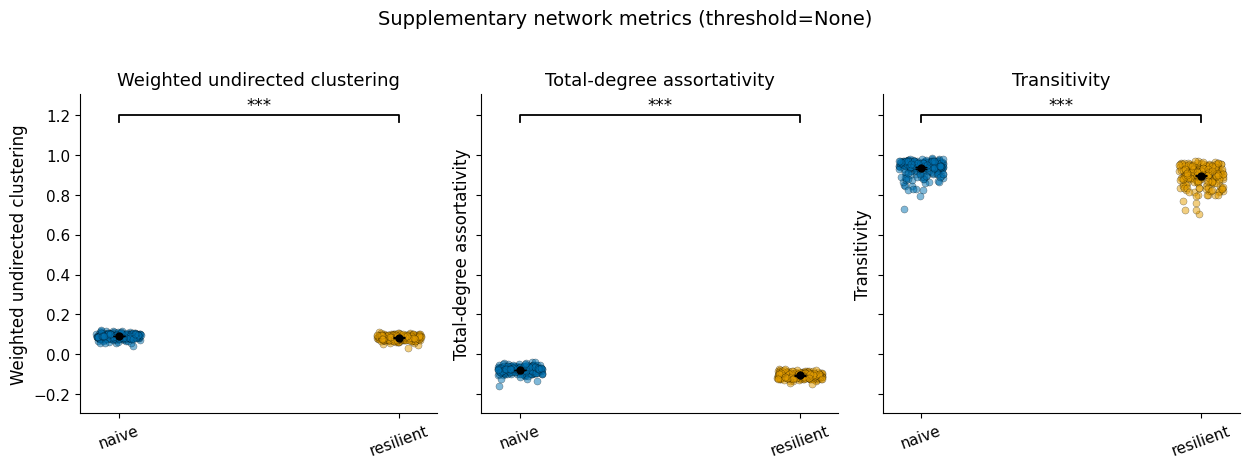

Saved plot files to:
/content/drive/MyDrive/RNN_NW_clustering_assort_transitivity_None_2026JUN24_0809


In [25]:
#%%
# ==========================================================
# Supplementary network metrics, threshold None
# Weighted undirected clustering + total-degree assortativity + transitivity
# naive vs resilient
# Mann-Whitney U test
# Saves png/svg/pdf + stats CSV
# SAME y-axis limits across all three subplots
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
from datetime import datetime
from scipy.stats import mannwhitneyu, pearsonr


RUN_TS_SUPP = datetime.now().strftime("%Y%b%d_%H%M").upper()

SUPP_OUT = Path("/content/drive/MyDrive") / f"RNN_NW_clustering_assort_transitivity_None_{RUN_TS_SUPP}"
SUPP_OUT.mkdir(parents=True, exist_ok=True)

print("Saving to:")
print(SUPP_OUT)


CONDITION_ORDER = ["naive", "resilient"]

COLORS = {
    "naive": "#0072B2",
    "resilient": "#E69F00",
}


def p_to_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def sem(x):
    x = np.asarray(x, dtype=float)
    return np.std(x, ddof=1) / np.sqrt(len(x))


def add_sig_bar(ax, x1, x2, y, h, text):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y+h, y+h, y],
        lw=1.3,
        color="black"
    )
    ax.text(
        (x1+x2)/2,
        y+h,
        text,
        ha="center",
        va="bottom",
        fontsize=12
    )


def get_undirected_abs_graph(W_rec):
    """
    Undirected weighted graph from EI/signed recurrent weights.

    W_rec[post, pre]
    Uses abs(W), removes self-loops, and symmetrizes with max(|W_ij|, |W_ji|).
    """

    W = np.asarray(W_rec, dtype=float).copy()
    W_abs = np.abs(W)
    np.fill_diagonal(W_abs, 0.0)

    W_undir = np.maximum(W_abs, W_abs.T)

    G = nx.from_numpy_array(
        W_undir,
        create_using=nx.Graph
    )

    return G, W_undir


def compute_weighted_undirected_clustering_none(W_rec):
    """
    Weighted undirected clustering using NetworkX.
    Direction is discarded.
    """

    G, _ = get_undirected_abs_graph(W_rec)

    return nx.average_clustering(
        G,
        weight="weight"
    )


def compute_total_degree_assortativity_none(W_rec):
    """
    Directed total-degree assortativity.

    Uses binary directed edges.
    W_rec[post, pre], therefore edge is pre -> post.

    Pearson correlation between:
        total degree of source nodes
        total degree of target nodes
    over all directed edges.
    """

    W = np.asarray(W_rec, dtype=float).copy()
    N = W.shape[0]

    offdiag = ~np.eye(N, dtype=bool)
    A = ((np.abs(W) > 0) & offdiag).astype(int)

    target_idx, source_idx = np.nonzero(A)

    if len(source_idx) < 2:
        return np.nan

    in_degree = A.sum(axis=1)
    out_degree = A.sum(axis=0)

    total_degree = in_degree + out_degree

    source_deg = total_degree[source_idx]
    target_deg = total_degree[target_idx]

    if np.std(source_deg) == 0 or np.std(target_deg) == 0:
        return np.nan

    r, _ = pearsonr(source_deg, target_deg)

    return r


def compute_transitivity_none(W_rec):
    """
    Binary undirected transitivity using NetworkX.

    Direction is discarded.
    Weights are ignored.
    Uses the undirected support graph.
    """

    _, W_undir = get_undirected_abs_graph(W_rec)

    A_undir = (W_undir > 0).astype(int)

    G_bin = nx.from_numpy_array(
        A_undir,
        create_using=nx.Graph
    )

    return nx.transitivity(G_bin)


# ----------------------------------------------------------
# Compute metrics
# ----------------------------------------------------------

rows = []

for condition in CONDITION_ORDER:

    for network_idx, W_rec in enumerate(
        loaded_networks[condition]["W_rec_list"]
    ):

        weighted_undirected_clustering = (
            compute_weighted_undirected_clustering_none(W_rec)
        )

        assortativity_total_degree = (
            compute_total_degree_assortativity_none(W_rec)
        )

        transitivity = compute_transitivity_none(W_rec)

        rows.append({
            "condition": condition,
            "network_idx": network_idx,
            "threshold": "None",
            "weighted_undirected_clustering": weighted_undirected_clustering,
            "assortativity_total_degree": assortativity_total_degree,
            "transitivity": transitivity,
        })


supp_df = pd.DataFrame(rows)

values_csv = SUPP_OUT / f"clustering_assort_transitivity_None_values_{RUN_TS_SUPP}.csv"
supp_df.to_csv(values_csv, index=False)

print("Saved values:")
print(values_csv)

display(supp_df.head())


# ----------------------------------------------------------
# Mann-Whitney U stats
# ----------------------------------------------------------

metric_info = {
    "weighted_undirected_clustering": "Weighted undirected clustering",
    "assortativity_total_degree": "Total-degree assortativity",
    "transitivity": "Transitivity",
}

stats_rows = []

for metric in metric_info.keys():

    a = supp_df[
        supp_df["condition"] == "naive"
    ][metric].dropna().values

    b = supp_df[
        supp_df["condition"] == "resilient"
    ][metric].dropna().values

    U, p = mannwhitneyu(
        a,
        b,
        alternative="two-sided"
    )

    stats_rows.append({
        "metric": metric,
        "threshold": "None",
        "naive_n": len(a),
        "naive_mean": np.mean(a),
        "naive_sd": np.std(a, ddof=1),
        "naive_median": np.median(a),
        "resilient_n": len(b),
        "resilient_mean": np.mean(b),
        "resilient_sd": np.std(b, ddof=1),
        "resilient_median": np.median(b),
        "U": U,
        "p": p,
        "sig": p_to_stars(p),
    })


stats_df = pd.DataFrame(stats_rows)

stats_csv = SUPP_OUT / f"clustering_assort_transitivity_None_mannwhitney_stats_{RUN_TS_SUPP}.csv"
stats_df.to_csv(stats_csv, index=False)

print("Saved stats:")
print(stats_csv)

display(stats_df)


# ----------------------------------------------------------
# Shared y-axis limits across all three plots
# ----------------------------------------------------------

all_plot_values = []

for metric in metric_info.keys():
    all_plot_values.extend(
        supp_df[metric].dropna().values.tolist()
    )

global_y_min = np.min(all_plot_values)
global_y_max = np.max(all_plot_values)

global_yr = global_y_max - global_y_min

if global_yr == 0:
    global_yr = 0.01

shared_y_min = global_y_min - 0.12 * global_yr
shared_y_max = global_y_max + 0.28 * global_yr


# ----------------------------------------------------------
# Plot supplementary metrics
# ----------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12.6, 4.5),
    facecolor="white",
    sharey=True
)

fig.patch.set_facecolor("white")

rng = np.random.default_rng(42)

for ax, metric in zip(axes, metric_info.keys()):

    ax.set_facecolor("white")

    a = supp_df[
        supp_df["condition"] == "naive"
    ][metric].dropna().values

    b = supp_df[
        supp_df["condition"] == "resilient"
    ][metric].dropna().values

    samples = [a, b]

    for x, condition, vals in zip([1, 2], CONDITION_ORDER, samples):

        jitter = rng.uniform(-0.08, 0.08, size=len(vals))

        ax.scatter(
            np.full(len(vals), x) + jitter,
            vals,
            s=26,
            alpha=0.50,
            color=COLORS[condition],
            edgecolor="black",
            linewidth=0.30,
            zorder=2
        )

        ax.errorbar(
            x,
            np.mean(vals),
            yerr=sem(vals),
            fmt="o",
            color="black",
            markersize=5,
            capsize=4,
            lw=1.0,
            zorder=5
        )

    stat_row = stats_df[stats_df["metric"] == metric].iloc[0]

    add_sig_bar(
        ax,
        1,
        2,
        shared_y_max - 0.12 * global_yr,
        0.03 * global_yr,
        stat_row["sig"]
    )

    ax.set_ylim(
        shared_y_min,
        shared_y_max
    )

    ax.set_xticks([1, 2])

    ax.set_xticklabels(
        ["naive", "resilient"],
        rotation=20
    )

    ax.set_ylabel(
        metric_info[metric],
        fontsize=12
    )

    ax.set_title(
        metric_info[metric],
        fontsize=13
    )

    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        labelsize=11,
        width=0.8
    )


fig.suptitle(
    "Supplementary network metrics (threshold=None)",
    fontsize=14,
    y=1.03
)

plt.tight_layout()


# ----------------------------------------------------------
# Save plot
# ----------------------------------------------------------

for ext in ["png", "svg", "pdf"]:

    plot_path = SUPP_OUT / f"clustering_assort_transitivity_None_naive_vs_resilient_{RUN_TS_SUPP}.{ext}"

    fig.savefig(
        plot_path,
        dpi=600,
        facecolor="white",
        edgecolor="none",
        bbox_inches="tight"
    )


plt.show()

print("Saved plot files to:")
print(SUPP_OUT)

Saving to:
/content/drive/MyDrive/RNN_NW_primary_metrics_SHARED_Y_None_2026JUN24_0815
Saved values:
/content/drive/MyDrive/RNN_NW_primary_metrics_SHARED_Y_None_2026JUN24_0815/primary_metrics_SHARED_Y_None_values_2026JUN24_0815.csv


,condition,network_idx,threshold,density,num_edges,n_possible,weighted_directed_reciprocity,reciprocated_weight,total_weight,local_efficiency
0,naive,0,None,0.887980,8791,9900,0.452160,711.789273,1574.196258,0.990001
1,naive,1,None,0.828687,8204,9900,0.438333,528.904620,1206.627853,0.975886
2,naive,2,None,0.884545,8757,9900,0.450901,798.840590,1771.654362,0.989787
3,naive,3,None,0.781414,7736,9900,0.434072,418.979396,965.229564,0.968062
4,naive,4,None,0.632828,6265,9900,0.388336,201.103366,517.859190,0.929250


Saved stats:
/content/drive/MyDrive/RNN_NW_primary_metrics_SHARED_Y_None_2026JUN24_0815/primary_metrics_SHARED_Y_None_mannwhitney_stats_2026JUN24_0815.csv


,metric,threshold,naive_n,naive_mean,naive_sd,naive_median,resilient_n,resilient_mean,resilient_sd,resilient_median,U,p,sig
0,density,None,200,0.790177,0.074962,0.807727,200,0.713105,0.087819,0.721667,30414.0,2.115423e-19,***
1,weighted_directed_reciprocity,None,200,0.435763,0.022709,0.441503,200,0.397724,0.026290,0.398529,35182.0,2.182841e-39,***
2,local_efficiency,None,200,0.968674,0.018099,0.972748,200,0.950339,0.023309,0.954510,30212.0,1.024672e-18,***


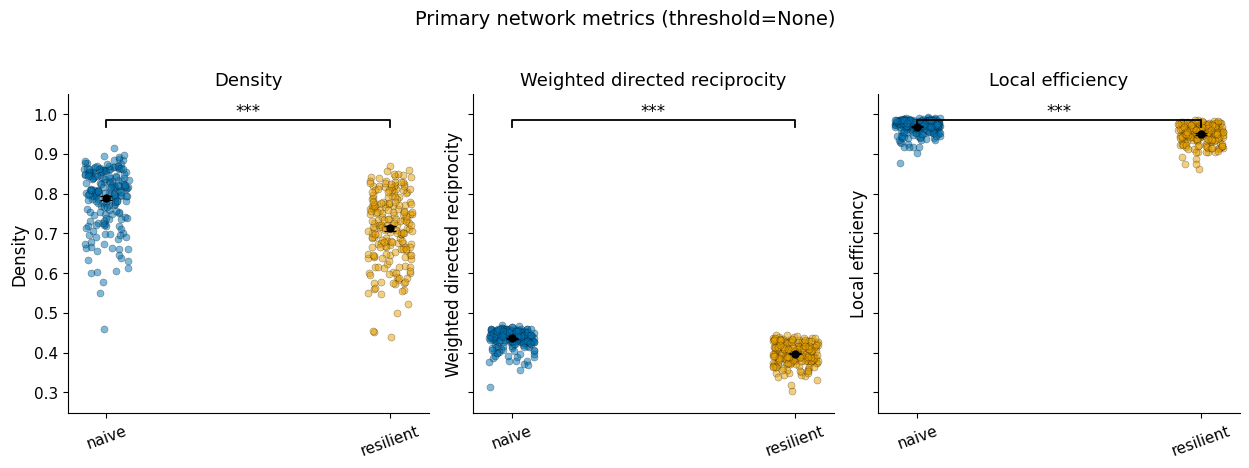

Saved plot files to:
/content/drive/MyDrive/RNN_NW_primary_metrics_SHARED_Y_None_2026JUN24_0815


In [26]:
#%%
# ==========================================================
# Publication-ready primary network metrics, threshold None
# Density + weighted directed reciprocity + local efficiency
# naive vs resilient
# Mann-Whitney U test
# Saves png/svg/pdf + stats CSV
# SAME y-axis limits across all three subplots
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
from datetime import datetime
from scipy.stats import mannwhitneyu


RUN_TS = datetime.now().strftime("%Y%b%d_%H%M").upper()

OUT = Path("/content/drive/MyDrive") / f"RNN_NW_primary_metrics_SHARED_Y_None_{RUN_TS}"
OUT.mkdir(parents=True, exist_ok=True)

print("Saving to:")
print(OUT)


CONDITION_ORDER = ["naive", "resilient"]

COLORS = {
    "naive": "#0072B2",
    "resilient": "#E69F00",
}


def p_to_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def sem(x):
    x = np.asarray(x, dtype=float)
    return np.std(x, ddof=1) / np.sqrt(len(x))


def add_sig_bar(ax, x1, x2, y, h, text):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y+h, y+h, y],
        lw=1.3,
        color="black"
    )
    ax.text(
        (x1+x2)/2,
        y+h,
        text,
        ha="center",
        va="bottom",
        fontsize=12
    )


def compute_density_none(W_rec):
    W = np.asarray(W_rec, dtype=float).copy()
    N = W.shape[0]

    offdiag = ~np.eye(N, dtype=bool)
    A = ((np.abs(W) > 0) & offdiag).astype(int)

    num_edges = int(A.sum())
    n_possible = int(N * (N - 1))
    density = num_edges / n_possible

    return density, num_edges, n_possible


def compute_weighted_directed_reciprocity_none(W_rec):
    W = np.asarray(W_rec, dtype=float).copy()
    W_abs = np.abs(W)
    np.fill_diagonal(W_abs, 0.0)

    total_weight = np.sum(W_abs)

    if total_weight == 0:
        return np.nan, 0.0, 0.0

    reciprocated_weight = np.sum(np.minimum(W_abs, W_abs.T))
    reciprocity = reciprocated_weight / total_weight

    return reciprocity, reciprocated_weight, total_weight


def compute_local_efficiency_none(W_rec):
    """
    Binary local efficiency on the undirected support graph.
    Direction is discarded.
    Signed EI weights are converted to absolute magnitudes.
    """

    W = np.asarray(W_rec, dtype=float).copy()
    W_abs = np.abs(W)
    np.fill_diagonal(W_abs, 0.0)

    W_undir = np.maximum(W_abs, W_abs.T)
    A_undir = (W_undir > 0).astype(int)

    G = nx.from_numpy_array(
        A_undir,
        create_using=nx.Graph
    )

    return nx.local_efficiency(G)


# ----------------------------------------------------------
# Compute metrics
# ----------------------------------------------------------

rows = []

for condition in CONDITION_ORDER:

    for network_idx, W_rec in enumerate(
        loaded_networks[condition]["W_rec_list"]
    ):

        density, num_edges, n_possible = compute_density_none(W_rec)

        reciprocity, reciprocated_weight, total_weight = (
            compute_weighted_directed_reciprocity_none(W_rec)
        )

        local_efficiency = compute_local_efficiency_none(W_rec)

        rows.append({
            "condition": condition,
            "network_idx": network_idx,
            "threshold": "None",
            "density": density,
            "num_edges": num_edges,
            "n_possible": n_possible,
            "weighted_directed_reciprocity": reciprocity,
            "reciprocated_weight": reciprocated_weight,
            "total_weight": total_weight,
            "local_efficiency": local_efficiency,
        })


metrics_df = pd.DataFrame(rows)

values_csv = OUT / f"primary_metrics_SHARED_Y_None_values_{RUN_TS}.csv"
metrics_df.to_csv(values_csv, index=False)

print("Saved values:")
print(values_csv)

display(metrics_df.head())


# ----------------------------------------------------------
# Mann-Whitney U stats
# ----------------------------------------------------------

metric_info = {
    "density": "Density",
    "weighted_directed_reciprocity": "Weighted directed reciprocity",
    "local_efficiency": "Local efficiency",
}

stats_rows = []

for metric in metric_info.keys():

    a = metrics_df[
        metrics_df["condition"] == "naive"
    ][metric].dropna().values

    b = metrics_df[
        metrics_df["condition"] == "resilient"
    ][metric].dropna().values

    U, p = mannwhitneyu(
        a,
        b,
        alternative="two-sided"
    )

    stats_rows.append({
        "metric": metric,
        "threshold": "None",
        "naive_n": len(a),
        "naive_mean": np.mean(a),
        "naive_sd": np.std(a, ddof=1),
        "naive_median": np.median(a),
        "resilient_n": len(b),
        "resilient_mean": np.mean(b),
        "resilient_sd": np.std(b, ddof=1),
        "resilient_median": np.median(b),
        "U": U,
        "p": p,
        "sig": p_to_stars(p),
    })


stats_df = pd.DataFrame(stats_rows)

stats_csv = OUT / f"primary_metrics_SHARED_Y_None_mannwhitney_stats_{RUN_TS}.csv"
stats_df.to_csv(stats_csv, index=False)

print("Saved stats:")
print(stats_csv)

display(stats_df)


# ----------------------------------------------------------
# Shared y-axis limits across all metrics
# ----------------------------------------------------------

all_values = []

for metric in metric_info.keys():
    all_values.extend(
        metrics_df[metric].dropna().values.tolist()
    )

global_y_min = np.min(all_values)
global_y_max = np.max(all_values)

global_yr = global_y_max - global_y_min

if global_yr == 0:
    global_yr = 0.01

shared_y_min = global_y_min - 0.08 * global_yr
shared_y_max = global_y_max + 0.22 * global_yr

# Optional hard clamp for these bounded metrics
shared_y_min = max(0.0, shared_y_min)
shared_y_max = min(1.05, shared_y_max)


# ----------------------------------------------------------
# Plot all three metrics with identical y-axis
# ----------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12.6, 4.5),
    facecolor="white",
    sharey=True
)

fig.patch.set_facecolor("white")

rng = np.random.default_rng(42)

for ax, metric in zip(axes, metric_info.keys()):

    ax.set_facecolor("white")

    a = metrics_df[
        metrics_df["condition"] == "naive"
    ][metric].dropna().values

    b = metrics_df[
        metrics_df["condition"] == "resilient"
    ][metric].dropna().values

    for x, condition, vals in zip([1, 2], CONDITION_ORDER, [a, b]):

        jitter = rng.uniform(-0.08, 0.08, size=len(vals))

        ax.scatter(
            np.full(len(vals), x) + jitter,
            vals,
            s=26,
            alpha=0.50,
            color=COLORS[condition],
            edgecolor="black",
            linewidth=0.30,
            zorder=2
        )

        ax.errorbar(
            x,
            np.mean(vals),
            yerr=sem(vals),
            fmt="o",
            color="black",
            markersize=5,
            capsize=4,
            lw=1.0,
            zorder=5
        )

    stat_row = stats_df[stats_df["metric"] == metric].iloc[0]

    sig_y = shared_y_max - 0.12 * global_yr
    sig_h = 0.025 * global_yr

    add_sig_bar(
        ax,
        1,
        2,
        sig_y,
        sig_h,
        stat_row["sig"]
    )

    ax.set_ylim(
        shared_y_min,
        shared_y_max
    )

    ax.set_xticks([1, 2])

    ax.set_xticklabels(
        ["naive", "resilient"],
        rotation=20
    )

    ax.set_ylabel(
        metric_info[metric],
        fontsize=12
    )

    ax.set_title(
        metric_info[metric],
        fontsize=13
    )

    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(
        axis="both",
        labelsize=11,
        width=0.8
    )


fig.suptitle(
    "Primary network metrics (threshold=None)",
    fontsize=14,
    y=1.03
)

plt.tight_layout()


# ----------------------------------------------------------
# Save plot
# ----------------------------------------------------------

for ext in ["png", "svg", "pdf"]:

    plot_path = OUT / f"primary_metrics_SHARED_Y_None_naive_vs_resilient_{RUN_TS}.{ext}"

    fig.savefig(
        plot_path,
        dpi=600,
        facecolor="white",
        edgecolor="none",
        bbox_inches="tight"
    )


plt.show()

print("Saved plot files to:")
print(OUT)

/tmp/ipykernel_11676/3326531896.py:324: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


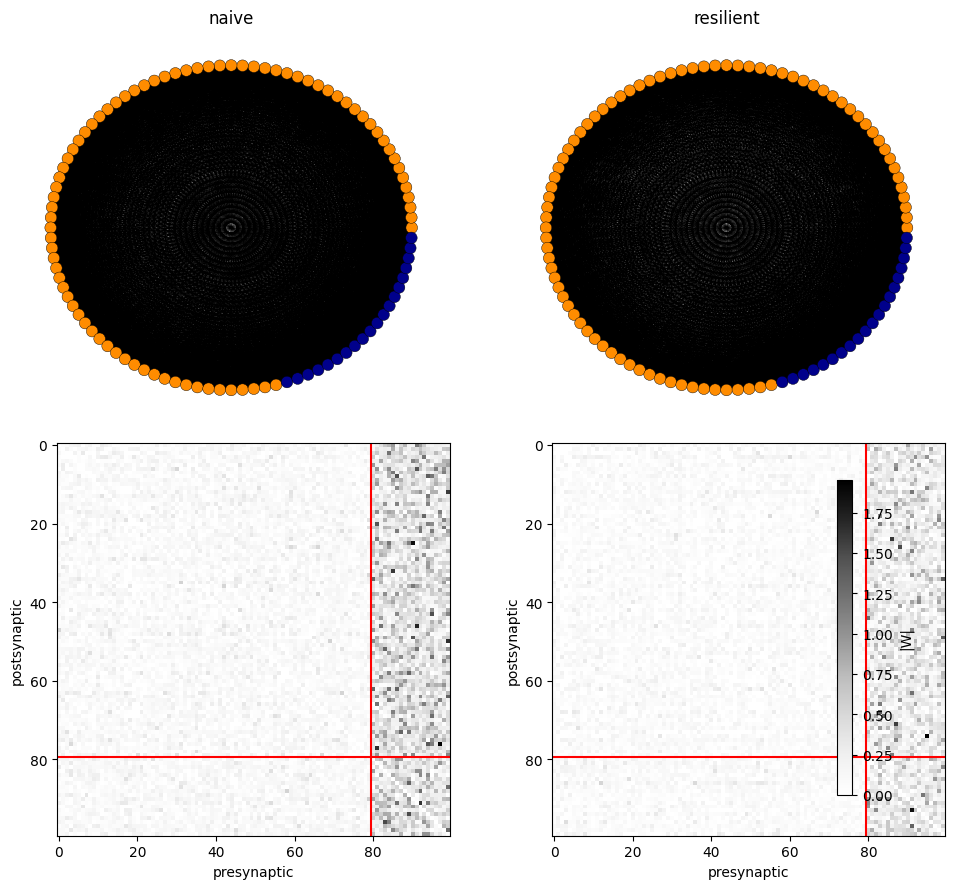

In [11]:
# ==========================================================
# Plot network + adjacency matrix
# threshold = None
# W_rec[post,pre]
# edge = pre -> post
# ==========================================================

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize


network_idx = 0


W_naive = loaded_networks["naive"]["W_rec_list"][network_idx]
W_res = loaded_networks["resilient"]["W_rec_list"][network_idx]

N_exc = loaded_networks["naive"]["N_exc"]


colors = {

    "E":"darkorange",
    "I":"darkblue"

}


def build_graph(W):

    G = nx.DiGraph()

    N = W.shape[0]

    G.add_nodes_from(range(N))


    for post in range(N):
        for pre in range(N):

            if pre==post:
                continue


            w = W[post,pre]

            if w==0:
                continue


            G.add_edge(

                pre,
                post,

                weight=w,
                alpha=np.abs(w)

            )


    return G



def draw_network(ax, W, title):


    G = build_graph(W)


    N = W.shape[0]


    pos = nx.circular_layout(G)



    node_colors=[]


    for i in range(N):

        if i < N_exc:
            node_colors.append(colors["E"])

        else:
            node_colors.append(colors["I"])



    edges = list(G.edges())


    weights = np.array([

        G[u][v]["alpha"]

        for u,v in edges

    ])


    weights = weights/weights.max()



    nx.draw_networkx_nodes(

        G,
        pos,

        node_size=70,

        node_color=node_colors,

        edgecolors='black',

        linewidths=0.3,

        ax=ax

    )



    nx.draw_networkx_edges(

        G,
        pos,


        edge_color='black',


        alpha=0.15,


        width=0.5,


        arrows=False,


        ax=ax

    )



    for (u,v),a in zip(edges,weights):


        nx.draw_networkx_edges(

            G,
            pos,

            edgelist=[(u,v)],

            edge_color='black',

            alpha=a,

            width=0.6,

            arrows=False,

            ax=ax

        )



    ax.set_title(title)

    ax.axis("off")



def draw_matrix(ax,W):



    im=ax.imshow(


        np.abs(W),

        cmap='Greys',

        interpolation='nearest'

    )



    ax.axhline(

        N_exc-0.5,

        color='red'

    )


    ax.axvline(

        N_exc-0.5,

        color='red'

    )



    ax.set_xlabel("presynaptic")

    ax.set_ylabel("postsynaptic")


    return im





fig=plt.figure(

        figsize=(10,9),

        facecolor='white'

)


gs=GridSpec(

        2,
        2,

        height_ratios=[2,2]

)





ax1=fig.add_subplot(gs[0,0])

draw_network(

        ax1,

        W_naive,

        'naive'

)





ax2=fig.add_subplot(gs[0,1])

draw_network(

        ax2,

        W_res,

        'resilient'

)




ax3=fig.add_subplot(gs[1,0])

im=draw_matrix(

        ax3,

        W_naive

)




ax4=fig.add_subplot(gs[1,1])

draw_matrix(

        ax4,

        W_res

)



cbar=fig.colorbar(

        im,

        ax=[ax3,ax4],

        fraction=0.03

)


cbar.set_label("|W|")



plt.tight_layout()

plt.show()

Saving to:
/content/drive/MyDrive/RNN_NW_graph_None_alpha_2026JUN24_0620


/tmp/ipykernel_11676/3107131639.py:327: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


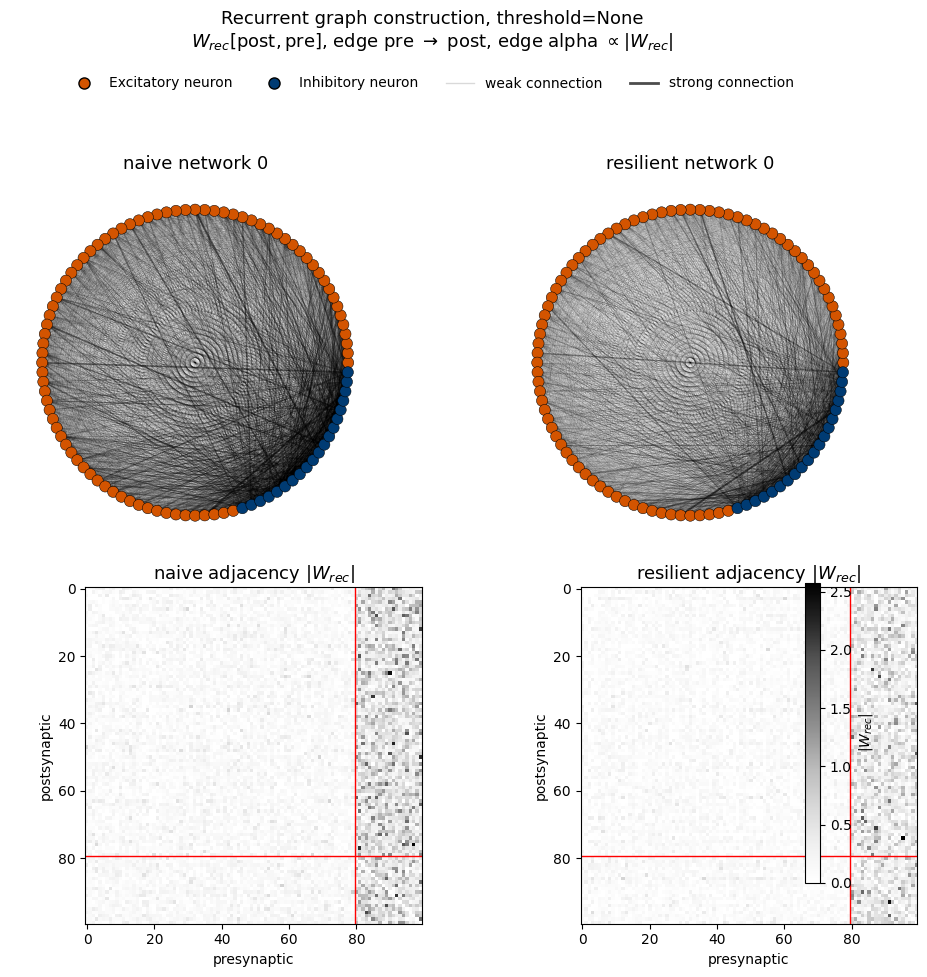

Saved to:
/content/drive/MyDrive/RNN_NW_graph_None_alpha_2026JUN24_0620


In [12]:
#%%
# ==========================================================
# Circular graph + adjacency matrix
# threshold = None
#
# W_rec[post, pre]
# edge = pre -> post
#
# Edge transparency alpha ∝ |W_rec|
# E nodes = dark orange
# I nodes = dark blue
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
from datetime import datetime


# ----------------------------------------------------------
# User settings
# ----------------------------------------------------------

network_idx = 0

RUN_TS_GRAPH = datetime.now().strftime("%Y%b%d_%H%M").upper()

GRAPH_OUT = (
    Path("/content/drive/MyDrive")
    / f"RNN_NW_graph_None_alpha_{RUN_TS_GRAPH}"
)

GRAPH_OUT.mkdir(parents=True, exist_ok=True)

print("Saving to:")
print(GRAPH_OUT)


CONDITION_ORDER = ["naive", "resilient"]

NODE_COLORS = {
    "E": "#D35400",   # dark orange
    "I": "#003B73",   # dark blue
}

EDGE_COLOR = "black"


# ----------------------------------------------------------
# Build graph
# ----------------------------------------------------------

def build_graph_none(W_rec):
    """
    Build directed graph from W_rec without threshold.

    W_rec[post, pre]
    edge = pre -> post
    """
    W = np.asarray(W_rec, dtype=float).copy()
    np.fill_diagonal(W, 0.0)

    N = W.shape[0]

    G = nx.DiGraph()
    G.add_nodes_from(range(N))

    post_idx, pre_idx = np.where(W != 0)

    for post, pre in zip(post_idx, pre_idx):

        w = float(W[post, pre])

        G.add_edge(
            int(pre),
            int(post),
            weight_signed=w,
            weight_abs=abs(w),
        )

    return G


def circular_layout_ei(N, N_exc):
    """
    Put all neurons on one circle.
    E neurons first, then I neurons.
    """
    pos = {}

    theta = np.linspace(
        0,
        2 * np.pi,
        N,
        endpoint=False
    )

    for node, angle in enumerate(theta):
        pos[node] = np.array([
            np.cos(angle),
            np.sin(angle)
        ])

    return pos


# ----------------------------------------------------------
# Draw graph with weighted alpha
# ----------------------------------------------------------

def draw_graph_alpha(ax, W_rec, N_exc, title):
    """
    Draw graph with edge alpha proportional to |W|.
    """
    G = build_graph_none(W_rec)

    N = W_rec.shape[0]

    pos = circular_layout_ei(N, N_exc)

    weights = np.array(
        [d["weight_abs"] for _, _, d in G.edges(data=True)],
        dtype=float
    )

    if len(weights) == 0:
        max_w = 1.0
    else:
        max_w = np.nanmax(weights)

    node_color_list = [
        NODE_COLORS["E"] if node < N_exc else NODE_COLORS["I"]
        for node in G.nodes()
    ]

    # nodes
    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_color_list,
        node_size=65,
        edgecolors="black",
        linewidths=0.35,
        ax=ax,
    )

    # edges drawn one by one so alpha can vary per edge
    for u, v, d in G.edges(data=True):

        alpha = 0.02 + 0.55 * (d["weight_abs"] / max_w)

        width = 0.15 + 1.20 * (d["weight_abs"] / max_w)

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=[(u, v)],
            edge_color=EDGE_COLOR,
            alpha=float(alpha),
            width=float(width),
            arrows=False,
            ax=ax,
        )

    ax.set_title(title, fontsize=13)
    ax.axis("off")
    ax.set_aspect("equal")


# ----------------------------------------------------------
# Draw adjacency matrix
# ----------------------------------------------------------

def draw_adjacency_abs(ax, W_rec, N_exc, title):
    """
    Plot |W_rec| adjacency matrix.

    rows = post
    cols = pre
    """
    W = np.abs(np.asarray(W_rec, dtype=float).copy())
    np.fill_diagonal(W, 0.0)

    vmax = np.nanmax(W)
    if vmax == 0 or np.isnan(vmax):
        vmax = 1.0

    im = ax.imshow(
        W,
        cmap="Greys",
        vmin=0,
        vmax=vmax,
        interpolation="nearest",
        aspect="equal",
    )

    ax.axhline(N_exc - 0.5, color="red", linewidth=1.0)
    ax.axvline(N_exc - 0.5, color="red", linewidth=1.0)

    ax.set_xlabel("presynaptic")
    ax.set_ylabel("postsynaptic")
    ax.set_title(title, fontsize=13)

    return im


# ----------------------------------------------------------
# Load selected networks
# ----------------------------------------------------------

W_naive = loaded_networks["naive"]["W_rec_list"][network_idx]
W_res = loaded_networks["resilient"]["W_rec_list"][network_idx]

N_exc = loaded_networks["naive"]["N_exc"]


# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 9),
    facecolor="white",
    gridspec_kw={"height_ratios": [1.1, 1.0]},
)

fig.patch.set_facecolor("white")

for ax in axes.ravel():
    ax.set_facecolor("white")


draw_graph_alpha(
    axes[0, 0],
    W_naive,
    N_exc,
    f"naive network {network_idx}",
)

draw_graph_alpha(
    axes[0, 1],
    W_res,
    N_exc,
    f"resilient network {network_idx}",
)

im1 = draw_adjacency_abs(
    axes[1, 0],
    W_naive,
    N_exc,
    r"naive adjacency $|W_{rec}|$",
)

im2 = draw_adjacency_abs(
    axes[1, 1],
    W_res,
    N_exc,
    r"resilient adjacency $|W_{rec}|$",
)


# shared colorbar
cbar = fig.colorbar(
    im2,
    ax=axes[1, :],
    fraction=0.035,
    pad=0.04,
)

cbar.set_label(r"$|W_{rec}|$")


# legend
legend_elements = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Excitatory neuron",
        markerfacecolor=NODE_COLORS["E"],
        markeredgecolor="black",
        markersize=8,
    ),
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Inhibitory neuron",
        markerfacecolor=NODE_COLORS["I"],
        markeredgecolor="black",
        markersize=8,
    ),
    plt.Line2D(
        [0], [0],
        color="black",
        alpha=0.15,
        lw=1,
        label="weak connection",
    ),
    plt.Line2D(
        [0], [0],
        color="black",
        alpha=0.7,
        lw=2,
        label="strong connection",
    ),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    "Recurrent graph construction, threshold=None\n"
    r"$W_{rec}[\mathrm{post},\mathrm{pre}]$, edge pre $\rightarrow$ post, edge alpha $\propto |W_{rec}|$",
    fontsize=13,
    y=1.08,
)

plt.tight_layout()


# ----------------------------------------------------------
# Save
# ----------------------------------------------------------

for ext in ["png", "svg", "pdf"]:
    outpath = (
        GRAPH_OUT
        / f"network_graph_adjacency_None_alpha_idx{network_idx}_{RUN_TS_GRAPH}.{ext}"
    )

    fig.savefig(
        outpath,
        dpi=600,
        facecolor="white",
        bbox_inches="tight",
    )

plt.show()

print("Saved to:")
print(GRAPH_OUT)

In [12]:
#%%
# ==========================================================
# Circular block-specific graph + adjacency matrix
# threshold = None
#
# W_rec[post, pre]
# edge = pre -> post
#
# Node color:
#   E = dark orange
#   I = dark blue
#
# Edge block marker at edge midpoint:
#   E->E = circle
#   E->I = square
#   I->E = diamond
#   I->I = triangle
#
# Edge alpha ∝ |W_rec|
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
from datetime import datetime


# ----------------------------------------------------------
# User settings
# ----------------------------------------------------------

network_idx = 0

RUN_TS_BLOCK = datetime.now().strftime("%Y%b%d_%H%M").upper()

GRAPH_BLOCK_OUT = (
    Path("/content/drive/MyDrive")
    / f"RNN_NW_graph_None_blocks_{RUN_TS_BLOCK}"
)

GRAPH_BLOCK_OUT.mkdir(parents=True, exist_ok=True)

print("Saving to:")
print(GRAPH_BLOCK_OUT)


CONDITION_ORDER = ["naive", "resilient"]

NODE_COLORS = {
    "E": "#D35400",   # dark orange
    "I": "#003B73",   # dark blue
}

EDGE_COLOR = "black"

BLOCK_MARKERS = {
    "E->E": "o",   # circle
    "E->I": "s",   # square
    "I->E": "D",   # diamond
    "I->I": "^",   # triangle
}


# ----------------------------------------------------------
# Helpers
# ----------------------------------------------------------

def neuron_type(idx, N_exc):
    return "E" if idx < N_exc else "I"


def edge_block(pre, post, N_exc):
    """
    Edge direction is pre -> post.
    """
    return f"{neuron_type(pre, N_exc)}->{neuron_type(post, N_exc)}"


def build_graph_none_blocks(W_rec, N_exc):
    """
    Build directed graph from W_rec without threshold.

    W_rec[post, pre]
    edge = pre -> post
    """
    W = np.asarray(W_rec, dtype=float).copy()
    np.fill_diagonal(W, 0.0)

    N = W.shape[0]

    G = nx.DiGraph()
    G.add_nodes_from(range(N))

    post_idx, pre_idx = np.where(W != 0)

    for post, pre in zip(post_idx, pre_idx):

        w = float(W[post, pre])

        block = edge_block(
            pre=pre,
            post=post,
            N_exc=N_exc,
        )

        G.add_edge(
            int(pre),
            int(post),
            weight_signed=w,
            weight_abs=abs(w),
            block=block,
        )

    return G


def circular_layout_ei(N):
    """
    One circular layout. Neurons are ordered by index:
    E neurons first, I neurons last.
    """
    pos = {}

    theta = np.linspace(
        0,
        2*np.pi,
        N,
        endpoint=False,
    )

    for node, angle in enumerate(theta):
        pos[node] = np.array([
            np.cos(angle),
            np.sin(angle),
        ])

    return pos


# ----------------------------------------------------------
# Draw network
# ----------------------------------------------------------

def draw_block_graph(ax, W_rec, N_exc, title):
    """
    Draw full graph with:
    - node color = E/I
    - edge alpha = |W|
    - block markers at edge midpoints
    """
    G = build_graph_none_blocks(
        W_rec=W_rec,
        N_exc=N_exc,
    )

    N = W_rec.shape[0]
    pos = circular_layout_ei(N)

    weights = np.array(
        [d["weight_abs"] for _, _, d in G.edges(data=True)],
        dtype=float,
    )

    max_w = np.nanmax(weights) if len(weights) else 1.0
    if max_w == 0:
        max_w = 1.0

    # ------------------------------------------------------
    # edges
    # ------------------------------------------------------

    for u, v, d in G.edges(data=True):

        strength = d["weight_abs"] / max_w

        alpha = 0.015 + 0.50 * strength
        width = 0.10 + 0.90 * strength

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=[(u, v)],
            edge_color=EDGE_COLOR,
            alpha=float(alpha),
            width=float(width),
            arrows=False,
            ax=ax,
        )

    # ------------------------------------------------------
    # edge block markers at edge midpoints
    # ------------------------------------------------------

    # To avoid overplotting too much, only show block markers
    # for the stronger half of edges in the visualisation.
    marker_threshold = np.quantile(weights, 0.50) if len(weights) else np.inf

    for u, v, d in G.edges(data=True):

        if d["weight_abs"] < marker_threshold:
            continue

        p1 = pos[u]
        p2 = pos[v]

        midpoint = 0.5 * (p1 + p2)

        block = d["block"]

        strength = d["weight_abs"] / max_w

        ax.scatter(
            midpoint[0],
            midpoint[1],
            marker=BLOCK_MARKERS[block],
            s=8 + 20 * strength,
            color="black",
            alpha=0.10 + 0.55 * strength,
            linewidths=0,
            zorder=3,
        )

    # ------------------------------------------------------
    # nodes
    # ------------------------------------------------------

    E_nodes = list(range(0, N_exc))
    I_nodes = list(range(N_exc, N))

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=E_nodes,
        node_color=NODE_COLORS["E"],
        node_size=70,
        edgecolors="black",
        linewidths=0.35,
        ax=ax,
        label="Excitatory",
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=I_nodes,
        node_color=NODE_COLORS["I"],
        node_size=70,
        edgecolors="black",
        linewidths=0.35,
        ax=ax,
        label="Inhibitory",
    )

    ax.set_title(title, fontsize=13)
    ax.axis("off")
    ax.set_aspect("equal")


# ----------------------------------------------------------
# Draw adjacency matrix
# ----------------------------------------------------------

def draw_adjacency_abs(ax, W_rec, N_exc, title):
    """
    Plot |W_rec| adjacency matrix.
    rows = post
    cols = pre
    """
    W = np.abs(
        np.asarray(W_rec, dtype=float).copy()
    )

    np.fill_diagonal(W, 0.0)

    vmax = np.nanmax(W)
    if vmax == 0 or np.isnan(vmax):
        vmax = 1.0

    im = ax.imshow(
        W,
        cmap="Greys",
        vmin=0,
        vmax=vmax,
        interpolation="nearest",
        aspect="equal",
    )

    ax.axhline(
        N_exc - 0.5,
        color="red",
        linewidth=1.0,
    )

    ax.axvline(
        N_exc - 0.5,
        color="red",
        linewidth=1.0,
    )

    ax.set_xlabel("presynaptic")
    ax.set_ylabel("postsynaptic")
    ax.set_title(title, fontsize=13)

    return im


# ----------------------------------------------------------
# Load selected networks
# ----------------------------------------------------------

W_naive = loaded_networks["naive"]["W_rec_list"][network_idx]
W_res = loaded_networks["resilient"]["W_rec_list"][network_idx]

N_exc = loaded_networks["naive"]["N_exc"]


# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 9),
    facecolor="white",
    gridspec_kw={"height_ratios": [1.15, 1.0]},
)

fig.patch.set_facecolor("white")

for ax in axes.ravel():
    ax.set_facecolor("white")


draw_block_graph(
    axes[0, 0],
    W_naive,
    N_exc,
    f"naive network {network_idx}",
)

draw_block_graph(
    axes[0, 1],
    W_res,
    N_exc,
    f"resilient network {network_idx}",
)

im1 = draw_adjacency_abs(
    axes[1, 0],
    W_naive,
    N_exc,
    r"naive adjacency $|W_{rec}|$",
)

im2 = draw_adjacency_abs(
    axes[1, 1],
    W_res,
    N_exc,
    r"resilient adjacency $|W_{rec}|$",
)


# ----------------------------------------------------------
# Colorbar
# ----------------------------------------------------------

cbar = fig.colorbar(
    im2,
    ax=axes[1, :],
    fraction=0.035,
    pad=0.04,
)

cbar.set_label(r"$|W_{rec}|$")


# ----------------------------------------------------------
# Legend
# ----------------------------------------------------------

legend_elements = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Excitatory neuron",
        markerfacecolor=NODE_COLORS["E"],
        markeredgecolor="black",
        markersize=8,
    ),
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Inhibitory neuron",
        markerfacecolor=NODE_COLORS["I"],
        markeredgecolor="black",
        markersize=8,
    ),
    plt.Line2D(
        [0], [0],
        marker="o",
        color="black",
        label="E→E",
        linestyle="None",
        markersize=6,
    ),
    plt.Line2D(
        [0], [0],
        marker="s",
        color="black",
        label="E→I",
        linestyle="None",
        markersize=6,
    ),
    plt.Line2D(
        [0], [0],
        marker="D",
        color="black",
        label="I→E",
        linestyle="None",
        markersize=6,
    ),
    plt.Line2D(
        [0], [0],
        marker="^",
        color="black",
        label="I→I",
        linestyle="None",
        markersize=6,
    ),
    plt.Line2D(
        [0], [0],
        color="black",
        alpha=0.15,
        lw=1,
        label="weak edge",
    ),
    plt.Line2D(
        [0], [0],
        color="black",
        alpha=0.70,
        lw=2,
        label="strong edge",
    ),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.035),
    fontsize=9,
)

fig.suptitle(
    "Recurrent graph construction, threshold=None\n"
    r"$W_{rec}[\mathrm{post},\mathrm{pre}]$, edge pre $\rightarrow$ post; "
    r"edge alpha $\propto |W_{rec}|$; marker shape = E/I block",
    fontsize=13,
    y=1.10,
)

plt.tight_layout()


# ----------------------------------------------------------
# Save
# ----------------------------------------------------------

for ext in ["png", "svg", "pdf"]:

    outpath = (
        GRAPH_BLOCK_OUT
        / f"network_graph_adjacency_None_blocks_idx{network_idx}_{RUN_TS_BLOCK}.{ext}"
    )

    fig.savefig(
        outpath,
        dpi=600,
        facecolor="white",
        bbox_inches="tight",
    )


plt.show()

print("Saved to:")
print(GRAPH_BLOCK_OUT)

Saving graph plots to:
/content/drive/MyDrive/RNN_NW_results_2026JUN_2026JUN24_0628/graph_plots


/tmp/ipykernel_11676/1344230762.py:468: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


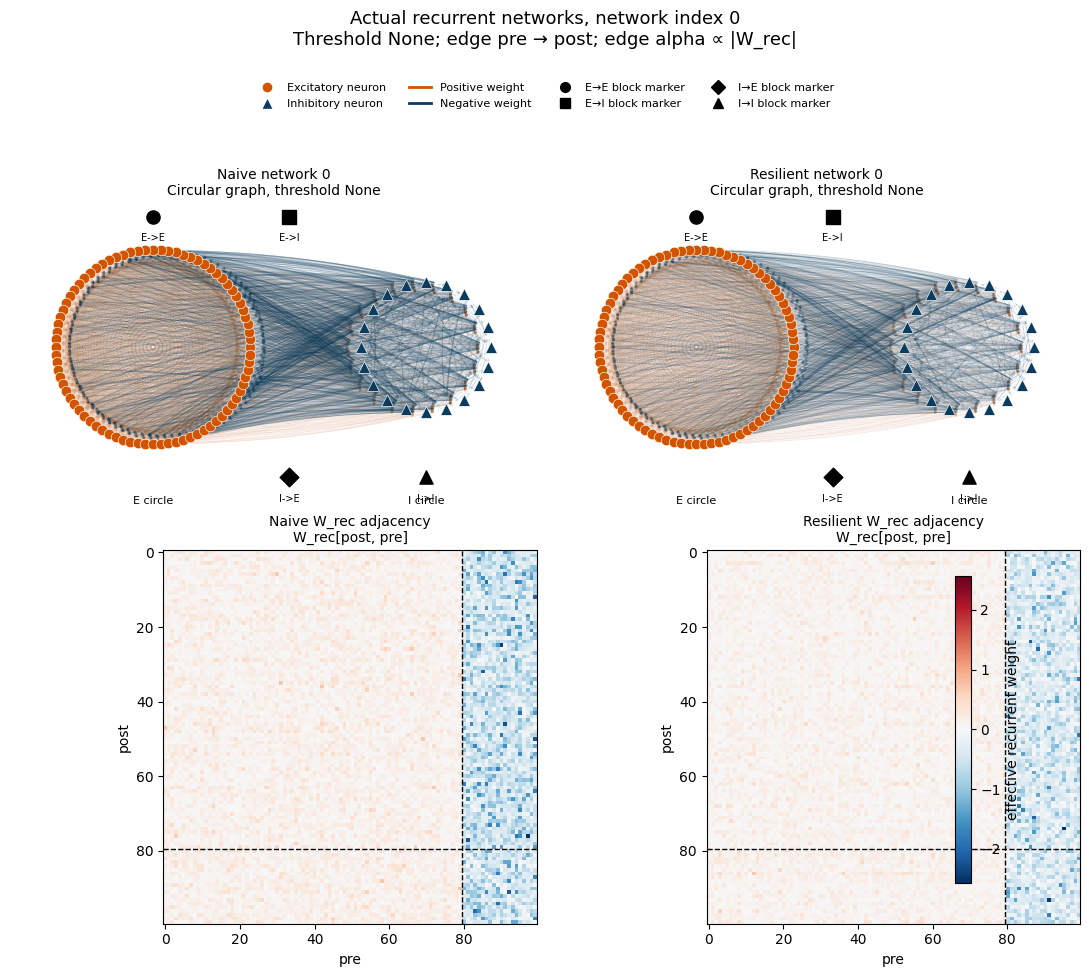

/tmp/ipykernel_11676/1344230762.py:468: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


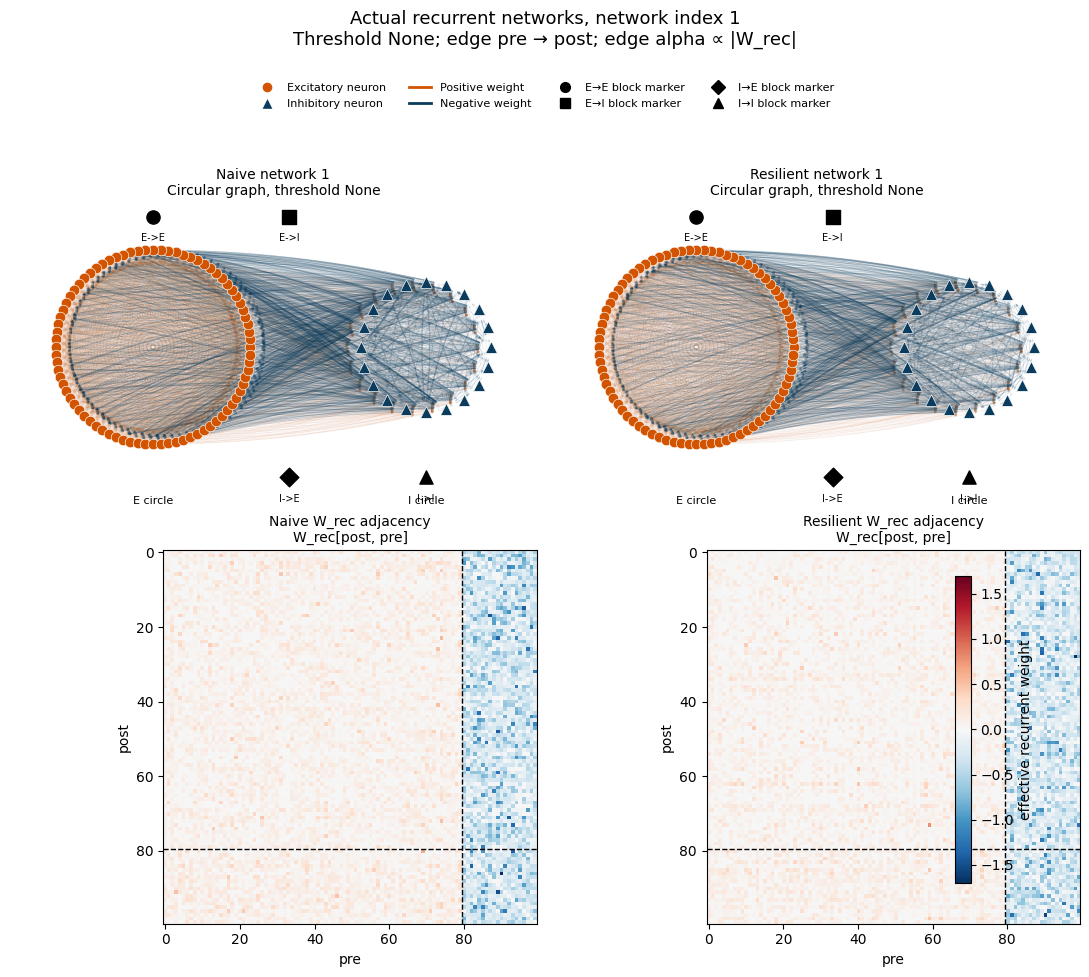

/tmp/ipykernel_11676/1344230762.py:468: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


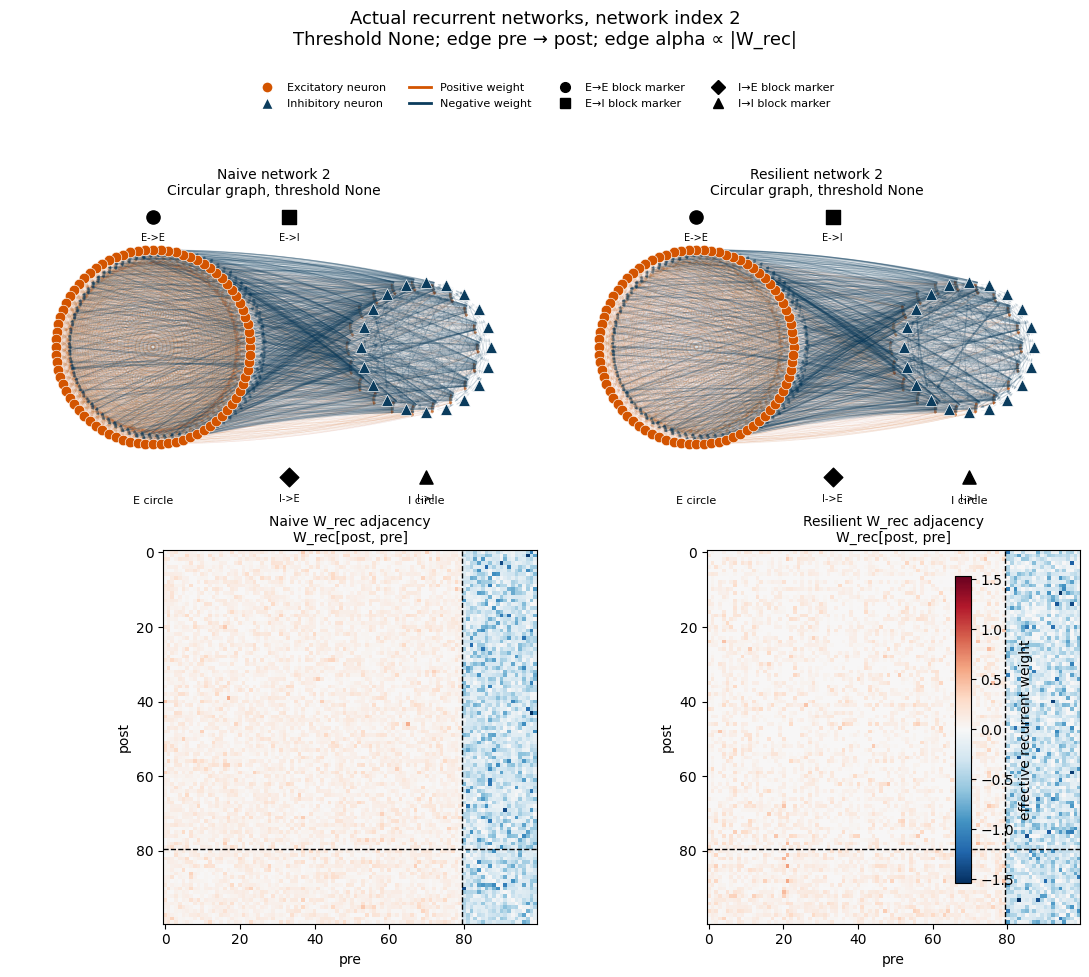

/tmp/ipykernel_11676/1344230762.py:468: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


In [ ]:
#%%
# ==========================================================
# Graph plots + adjacency matrices
# Threshold: None only
#
# For selected network indices:
#   - left: naive
#   - right: resilient
#   - circular graph with E/I node colors
#   - node shapes encode source/target block role:
#       E->E : circle
#       E->I : square
#       I->E : diamond
#       I->I : triangle
#   - edge alpha encodes |weight|
#   - adjacency matrix saved in same folder
#
# Saves png/svg/pdf into:
#   .../graph_plots/<timestamp>/
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from pathlib import Path
from datetime import datetime
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ----------------------------------------------------------
# User settings
# ----------------------------------------------------------

network_idx_list = [0, 1, 2, 3, 4]   # adapt this list as needed

RUN_TS_GRAPH = datetime.now().strftime("%Y%b%d_%H%M").upper()

GRAPH_PLOTS_DIR = Path("/content/drive/MyDrive") / f"RNN_NW_results_2026JUN_{RUN_TS_GRAPH}" / "graph_plots"
GRAPH_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("Saving graph plots to:")
print(GRAPH_PLOTS_DIR)


# ----------------------------------------------------------
# Plot style
# ----------------------------------------------------------

NODE_COLORS = {
    "E": "#D35400",   # dark orange
    "I": "#0B3C5D",   # dark blue
}

EDGE_COLORS = {
    "positive": "#D35400",
    "negative": "#0B3C5D",
}

BLOCK_MARKERS = {
    "E->E": "o",   # circle
    "E->I": "s",   # square
    "I->E": "D",   # diamond / raute
    "I->I": "^",   # triangle
}


# ----------------------------------------------------------
# Helpers
# ----------------------------------------------------------

def save_fig_all_formats(fig, basepath, dpi=300):
    for ext in ["png", "svg", "pdf"]:
        fig.savefig(f"{basepath}.{ext}", dpi=dpi, bbox_inches="tight")


def get_block_of_edge(pre, post, N_exc):
    pre_type = "E" if pre < N_exc else "I"
    post_type = "E" if post < N_exc else "I"
    return f"{pre_type}->{post_type}"


def circular_positions_by_population(N, N_exc):
    """
    E and I nodes are placed on two separated circles.
    """
    pos = {}

    E_nodes = np.arange(0, N_exc)
    I_nodes = np.arange(N_exc, N)

    theta_E = np.linspace(0, 2 * np.pi, len(E_nodes), endpoint=False)
    theta_I = np.linspace(0, 2 * np.pi, len(I_nodes), endpoint=False)

    # left circle = E
    for node, theta in zip(E_nodes, theta_E):
        pos[int(node)] = np.array([
            -1.15 + 0.82 * np.cos(theta),
             0.00 + 0.82 * np.sin(theta),
        ])

    # right circle = I
    for node, theta in zip(I_nodes, theta_I):
        pos[int(node)] = np.array([
             1.15 + 0.55 * np.cos(theta),
             0.00 + 0.55 * np.sin(theta),
        ])

    return pos


def build_full_graph_none(W_rec):
    """
    Build full weighted directed graph.

    Convention:
        W_rec[post, pre]
        edge: pre -> post

    No quantile threshold.
    Only zero weights and self-loops are excluded.
    """
    W = np.asarray(W_rec, dtype=float).copy()
    np.fill_diagonal(W, 0.0)

    N = W.shape[0]

    G = nx.DiGraph()
    G.add_nodes_from(range(N))

    post_idx, pre_idx = np.where(W != 0)

    for post, pre in zip(post_idx, pre_idx):
        signed_w = float(W[post, pre])
        abs_w = abs(signed_w)

        G.add_edge(
            int(pre),
            int(post),
            weight_signed=signed_w,
            weight_abs=abs_w,
            sign="positive" if signed_w > 0 else "negative",
            block=get_block_of_edge(pre, post, N_exc=80),  # overwritten below if needed
        )

    return G


def plot_single_network_graph(ax, W_rec, N_exc, condition, title):
    """
    Circular graph plot for one network.
    Shows all non-zero edges.
    Edge alpha scales with |W|.
    Node color = E/I.
    Node shape = dominant outgoing block class for readability.
    """
    W = np.asarray(W_rec, dtype=float).copy()
    np.fill_diagonal(W, 0.0)

    N = W.shape[0]
    G = nx.DiGraph()
    G.add_nodes_from(range(N))

    post_idx, pre_idx = np.where(W != 0)

    for post, pre in zip(post_idx, pre_idx):
        signed_w = float(W[post, pre])
        abs_w = abs(signed_w)

        G.add_edge(
            int(pre),
            int(post),
            weight_signed=signed_w,
            weight_abs=abs_w,
            sign="positive" if signed_w > 0 else "negative",
            block=get_block_of_edge(pre, post, N_exc),
        )

    pos = circular_positions_by_population(N, N_exc)

    all_abs = np.array(
        [d["weight_abs"] for _, _, d in G.edges(data=True)],
        dtype=float,
    )

    if len(all_abs) == 0:
        max_abs = 1.0
    else:
        max_abs = np.nanmax(all_abs)

    # Draw edges block-wise, sign by color, magnitude by alpha
    for sign_name in ["positive", "negative"]:
        edgelist = [
            (u, v)
            for u, v, d in G.edges(data=True)
            if d["sign"] == sign_name
        ]

        if len(edgelist) == 0:
            continue

        edge_alphas = [
            0.03 + 0.35 * (G[u][v]["weight_abs"] / max_abs)
            for u, v in edgelist
        ]

        edge_widths = [
            0.15 + 1.20 * (G[u][v]["weight_abs"] / max_abs)
            for u, v in edgelist
        ]

        # NetworkX does not support individual alpha robustly in all versions,
        # so draw edges one by one.
        for (u, v), alpha, width in zip(edgelist, edge_alphas, edge_widths):
            nx.draw_networkx_edges(
                G,
                pos,
                edgelist=[(u, v)],
                ax=ax,
                edge_color=EDGE_COLORS[sign_name],
                alpha=float(alpha),
                width=float(width),
                arrows=True,
                arrowsize=4,
                connectionstyle="arc3,rad=0.06",
            )

    # Node markers: use block role approximated by node population and outgoing target population.
    # E nodes are split into E->E and E->I role by marker.
    # I nodes are split into I->E and I->I role by marker.
    E_nodes = list(range(0, N_exc))
    I_nodes = list(range(N_exc, N))

    # For visual block encoding:
    # E source nodes: circle; I source nodes: triangle.
    # To still show all four shapes, add small overlay markers for block anchors.
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=E_nodes,
        node_color=NODE_COLORS["E"],
        node_shape="o",
        node_size=58,
        edgecolors="white",
        linewidths=0.45,
        ax=ax,
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=I_nodes,
        node_color=NODE_COLORS["I"],
        node_shape="^",
        node_size=70,
        edgecolors="white",
        linewidths=0.45,
        ax=ax,
    )

    # Block symbols as anchors around the plot
    anchor_positions = {
        "E->E": (-1.15,  1.10),
        "E->I": ( 0.00,  1.10),
        "I->E": ( 0.00, -1.10),
        "I->I": ( 1.15, -1.10),
    }

    for block, (x, y) in anchor_positions.items():
        ax.scatter(
            x,
            y,
            s=90,
            marker=BLOCK_MARKERS[block],
            color="black",
            zorder=10,
        )
        ax.text(
            x,
            y - 0.14,
            block,
            ha="center",
            va="top",
            fontsize=7,
        )

    ax.text(-1.15, -1.32, "E circle", ha="center", fontsize=8)
    ax.text(1.15, -1.32, "I circle", ha="center", fontsize=8)

    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal")
    ax.axis("off")


def plot_single_adjacency(ax, W_rec, N_exc, condition, title):
    """
    Signed adjacency matrix of actual W_rec.
    No threshold.
    """
    W = np.asarray(W_rec, dtype=float).copy()
    np.fill_diagonal(W, 0.0)

    vmax = np.nanmax(np.abs(W))
    if vmax == 0 or np.isnan(vmax):
        vmax = 1.0

    im = ax.imshow(
        W,
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
        interpolation="nearest",
        aspect="equal",
    )

    ax.axvline(N_exc - 0.5, color="black", linestyle="--", linewidth=1)
    ax.axhline(N_exc - 0.5, color="black", linestyle="--", linewidth=1)

    ax.set_xlabel("pre")
    ax.set_ylabel("post")
    ax.set_title(title, fontsize=10)

    return im


def create_combined_naive_resilient_plot(network_idx):
    """
    One figure per network index:
        left: naive graph + adjacency
        right: resilient graph + adjacency
    """
    W_naive = loaded_networks["naive"]["W_rec_list"][network_idx]
    W_res = loaded_networks["resilient"]["W_rec_list"][network_idx]

    N_exc_naive = loaded_networks["naive"]["N_exc"]
    N_exc_res = loaded_networks["resilient"]["N_exc"]

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(11, 9),
        gridspec_kw={"height_ratios": [1.05, 1.0]},
    )

    plot_single_network_graph(
        axes[0, 0],
        W_naive,
        N_exc_naive,
        "naive",
        f"Naive network {network_idx}\nCircular graph, threshold None",
    )

    plot_single_network_graph(
        axes[0, 1],
        W_res,
        N_exc_res,
        "resilient",
        f"Resilient network {network_idx}\nCircular graph, threshold None",
    )

    im1 = plot_single_adjacency(
        axes[1, 0],
        W_naive,
        N_exc_naive,
        "naive",
        "Naive W_rec adjacency\nW_rec[post, pre]",
    )

    im2 = plot_single_adjacency(
        axes[1, 1],
        W_res,
        N_exc_res,
        "resilient",
        "Resilient W_rec adjacency\nW_rec[post, pre]",
    )

    # one shared colorbar
    cbar = fig.colorbar(
        im2,
        ax=axes[1, :],
        fraction=0.035,
        pad=0.04,
    )
    cbar.set_label("effective recurrent weight")

    legend_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            label="Excitatory neuron",
            markerfacecolor=NODE_COLORS["E"],
            markeredgecolor="white",
            markersize=8,
        ),
        Line2D(
            [0], [0],
            marker="^",
            color="w",
            label="Inhibitory neuron",
            markerfacecolor=NODE_COLORS["I"],
            markeredgecolor="white",
            markersize=8,
        ),
        Line2D(
            [0], [0],
            color=EDGE_COLORS["positive"],
            lw=2,
            label="Positive weight",
        ),
        Line2D(
            [0], [0],
            color=EDGE_COLORS["negative"],
            lw=2,
            label="Negative weight",
        ),
        Line2D(
            [0], [0],
            marker="o",
            color="black",
            label="E→E block marker",
            markersize=7,
            linestyle="None",
        ),
        Line2D(
            [0], [0],
            marker="s",
            color="black",
            label="E→I block marker",
            markersize=7,
            linestyle="None",
        ),
        Line2D(
            [0], [0],
            marker="D",
            color="black",
            label="I→E block marker",
            markersize=7,
            linestyle="None",
        ),
        Line2D(
            [0], [0],
            marker="^",
            color="black",
            label="I→I block marker",
            markersize=7,
            linestyle="None",
        ),
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=4,
        frameon=False,
        fontsize=8,
        bbox_to_anchor=(0.5, 1.01),
    )

    fig.suptitle(
        f"Actual recurrent networks, network index {network_idx}\n"
        "Threshold None; edge pre → post; edge alpha ∝ |W_rec|",
        fontsize=13,
        y=1.08,
    )

    plt.tight_layout()

    base = GRAPH_PLOTS_DIR / f"actual_network_idx{network_idx}_naive_left_resilient_right_None_{RUN_TS_GRAPH}"

    save_fig_all_formats(fig, base)

    plt.show()
    plt.close(fig)


# ----------------------------------------------------------
# Run selected network indices
# ----------------------------------------------------------

for network_idx in network_idx_list:
    create_combined_naive_resilient_plot(network_idx)

print("Saved plots to:")
print(GRAPH_PLOTS_DIR)

In [ ]:
#------------- wihout betweenness shorter

In [ ]:
#%%
# ==========================================================
# Density only, threshold q=0.50
# naive vs resilient
# Mann-Whitney U test
# Saves png/svg/pdf + stats CSV
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from scipy.stats import mannwhitneyu


RUN_TS_DENSITY = datetime.now().strftime("%Y%b%d_%H%M").upper()

DENSITY_OUT = (
    Path("/content/drive/MyDrive")
    / f"RNN_NW_density_q50_{RUN_TS_DENSITY}"
)

DENSITY_OUT.mkdir(parents=True, exist_ok=True)


CONDITION_ORDER = ["naive", "resilient"]


COLORS = {
    "naive": "#0072B2",
    "resilient": "#E69F00",
}


def p_to_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def sem(x):
    x = np.asarray(x)
    return np.std(x, ddof=1)/np.sqrt(len(x))


def add_sig_bar(ax, x1, x2, y, h, text):

    ax.plot(
        [x1,x1,x2,x2],
        [y,y+h,y+h,y],
        lw=1.3,
        color='black'
    )

    ax.text(
        (x1+x2)/2,
        y+h,
        text,
        ha='center',
        va='bottom',
        fontsize=12
    )


def compute_density_q(W_rec, q=0.50):

    W = np.abs(
        np.asarray(W_rec, dtype=float)
    )


    N = W.shape[0]

    offdiag = ~np.eye(N, dtype=bool)

    vals = W[offdiag]


    thr = np.quantile(vals, q)


    A = (

        (W >= thr)

        & offdiag

    ).astype(int)



    num_edges = int(A.sum())


    n_possible = int(

        N*(N-1)

    )


    density = num_edges / n_possible



    return density, num_edges, n_possible, thr



############################################################

rows=[]


for condition in CONDITION_ORDER:


    for network_idx,W_rec in enumerate(

            loaded_networks[condition]["W_rec_list"]

    ):


        density,num_edges,n_possible,thr = compute_density_q(

                W_rec,

                q=0.50

        )



        rows.append({


            "condition":condition,

            "network_idx":network_idx,

            "threshold":0.50,

            "threshold_value":thr,

            "density":density,

            "num_edges":num_edges,

            "n_possible":n_possible

        })



density_df = pd.DataFrame(rows)



density_csv = (

        DENSITY_OUT

        /

        f"density_q50_values_{RUN_TS_DENSITY}.csv"

)


density_df.to_csv(

        density_csv,

        index=False

)


display(density_df.head())


############################################################
# statistics
############################################################

a = density_df.query(

        "condition=='naive'"

)["density"].values



b = density_df.query(

        "condition=='resilient'"

)["density"].values




U,p = mannwhitneyu(

        a,

        b,

        alternative='two-sided'

)



stats_df = pd.DataFrame([{

    "metric":"density",

    "threshold":0.50,


    "naive_n":len(a),
    "naive_mean":np.mean(a),
    "naive_sd":np.std(a),
    "naive_median":np.median(a),


    "resilient_n":len(b),
    "resilient_mean":np.mean(b),
    "resilient_sd":np.std(b),
    "resilient_median":np.median(b),



    "U":U,
    "p":p,

    "sig":p_to_stars(p)

}])


stats_csv = (

        DENSITY_OUT

        /

        f"density_q50_stats_{RUN_TS_DENSITY}.csv"

)


stats_df.to_csv(

        stats_csv,

        index=False

)

display(stats_df)



############################################################
# plot
############################################################

fig,ax = plt.subplots(

        figsize=(4.2,4.5),

        facecolor='white'

)


fig.patch.set_facecolor('white')
ax.set_facecolor('white')



rng=np.random.default_rng(42)



for x,cond,vals in zip(

        [1,2],

        CONDITION_ORDER,

        [a,b]

):


    jitter = rng.uniform(

            -0.08,

            0.08,

            len(vals)

    )


    ax.scatter(

        np.full(len(vals),x)+jitter,

        vals,


        s=26,

        alpha=.5,


        color=COLORS[cond],

        edgecolor='black',

        linewidth=.30

    )


    ax.errorbar(

        x,

        np.mean(vals),

        yerr=sem(vals),

        fmt='o',

        color='black',

        capsize=4

    )



ymin=min(np.min(a),np.min(b))
ymax=max(np.max(a),np.max(b))

yr=ymax-ymin

if yr==0:
    yr=.01



add_sig_bar(

        ax,

        1,

        2,

        ymax+.06*yr,

        .02*yr,

        p_to_stars(p)

)



ax.set_ylim(

        ymin-.08*yr,

        ymax+.22*yr

)



ax.set_xticks([1,2])

ax.set_xticklabels(

        ["naive","resilient"],

        rotation=20

)



ax.set_ylabel(

        "Density",

        fontsize=12

)



ax.set_title(

        "Network density (q=0.50)",

        fontsize=13

)



ax.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(.8)
ax.spines["bottom"].set_linewidth(.8)



plt.tight_layout()



for ext in [

        "png",

        "svg",

        "pdf"

]:


    path = (

        DENSITY_OUT

        /

        f"density_q50_naive_vs_resilient_{RUN_TS_DENSITY}.{ext}"

    )


    fig.savefig(

            path,

            dpi=600,

            facecolor='white',

            bbox_inches='tight'

    )


plt.show()


print("\nSaved to:")
print(DENSITY_OUT)

In [ ]:
"""

                 PRE neurons
             E(0-79)    I(80-99)

POST  E  -------------------------
      |    E→E      |    I→E
      |
      |
      I  -------------------------
      |    E→I      |    I→I
      """

In [ ]:
#-----

---


# Network analysis pipeline: naive vs resilient_SUpItoE

Colab-ready pipeline for recurrent ANN `W_rec`.

Thresholds requested by PI:
- `None`: all non-zero off-diagonal edges
- `0.30`: strongest 70%
- `0.70`: strongest 30%
- `0.80`: strongest 20% main threshold
- `0.90`: strongest 10%

Main focus:
- density, sparsity, redundancy
- I→E compared to E→E
- I→I because it is not directly touched by the stress
- directed and weighted directed network metrics for all thresholds
- spectral metrics

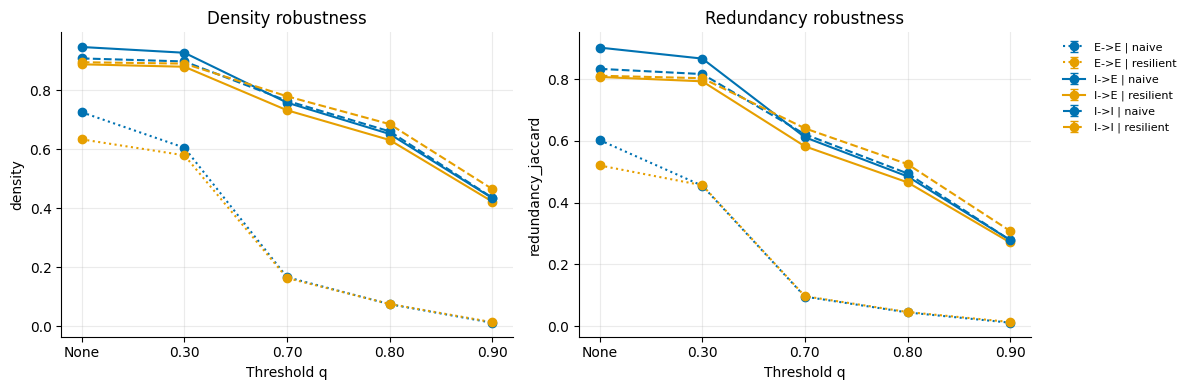


## Threshold robustness

This figure evaluates whether the inferred network organization depends on the specific threshold used for graph construction.

Binary directed graphs were generated by retaining progressively stronger fractions of recurrent connections:

| Quantile q | Retained edges |
|-----------|----------------|
| None | 100% |
| 0.30 | 70% |
| 0.70 | 30% |
| 0.80 | 20% |
| 0.90 | 10% |

For each threshold, graph density and redundancy were computed separately for the

* E→E subnetworks
* I→E subnetworks
* I→I subnetworks

---

### Density robustness

Network density was calculated as

\[
Density = \frac{E}{N(N-1)}
\]

where \(E\) denotes the number of existing directed edges.

The E→E and I→I subnetworks exhibit a gradual decrease in density with increasing threshold stringency and remain relatively densely connected even at higher thresholds.

In contrast, the I→E subnetworks rapidly lose connectivity as weaker edges are removed. This suggests that inhibitory projections onto excitatory neurons are concentrated within a comparatively small subset of stronger inhibitory connections.

Overall, density profiles are highly similar between naïve and resilient networks, indicating that the observed structural organization is largely robust to threshold selection.

---

### Redundancy robustness

Redundancy was estimated using pairwise Jaccard overlap coefficients, which quantify the extent to which neurons share common presynaptic inputs.

Higher values indicate the presence of multiple alternative pathways, whereas lower values reflect more specialized connectivity.

The E→E and I→I subnetworks show a smooth decline in redundancy across thresholds, suggesting a distributed and robust organization.

The I→E subnetworks display a marked reduction in shared inhibitory inputs at stringent thresholds, indicating that only a small subset of strong inhibitory projections remains common across excitatory neurons.

---

### Interpretation

These results demonstrate that the major structural conclusions are not strongly dependent on the chosen graph threshold.

In particular,

* E→E and I→I connectivity patterns appear robust across threshold choices.
* I→E connectivity is mediated by a relatively sparse subset of stronger inhibitory projections.
* The similarity between naïve and resilient networks across thresholds suggests that resilience training does not globally alter network density, but may instead induce more subtle redistributions within inhibitory subnetworks.

This analysis supports the use of **q = 0.80** as the primary threshold for graph construction, while confirming that the main findings are preserved across a broad range of threshold values.
